# CHORD UV Coverage & Dirty Beam Analysis

Evaluate how different antenna configurations (compact core, outrigger stations A and B)
affect UV coverage and angular resolution at 900 MHz.

In [5]:
from astropy.coordinates import EarthLocation
import matplotlib.pyplot as plt

import importlib
import sys
importlib.invalidate_caches()
sys.modules.pop("uv_utils", None)
from uv_utils import (
    utm_txt_to_earthlocations,
    combine_locations,
    setup_uvdata,
    plot_antenna_positions,
    plot_uv_coverage,
    compute_dirty_beam,
    adaptive_briggs_sweep,
    plot_briggs_values,
    _apply_weighting
)

drao_loc = EarthLocation.of_site("DRAO")
FREQ_HZ = 900e6

## Load Antenna Layouts

In [3]:
compact    = utm_txt_to_earthlocations("../../geo_data/layouts/shifted_SW_trimmed2.txt")
location_A = utm_txt_to_earthlocations("../../geo_data/layouts/location_A.txt")
location_A2 = utm_txt_to_earthlocations("../../geo_data/layouts/location_A_2.txt")
location_B = utm_txt_to_earthlocations("../../geo_data/layouts/location_B.txt")
location_C = utm_txt_to_earthlocations("../../geo_data/layouts/location_C.txt")
location_D = utm_txt_to_earthlocations("../../geo_data/layouts/location_D.txt")
location_E = utm_txt_to_earthlocations("../../geo_data/layouts/location_E.txt")
location_F = utm_txt_to_earthlocations("../../geo_data/layouts/location_F.txt")
location_G = utm_txt_to_earthlocations("../../geo_data/layouts/location_G.txt")

compact_A  = combine_locations(compact, location_A)
compact_B  = combine_locations(compact, location_B)
compact_AB = combine_locations(compact, location_A, location_B)
compact_A2 = combine_locations(compact, location_A2)
compact_C  = combine_locations(compact, location_C)
compact_D  = combine_locations(compact, location_D)
compact_E  = combine_locations(compact, location_E)
compact_F  = combine_locations(compact, location_F)
compact_G  = combine_locations(compact, location_G)

complete = combine_locations(compact, location_A, location_B, location_C, location_D, location_E, location_F, location_G)

Loaded 512 antennas from '../../geo_data/layouts/shifted_SW_trimmed2.txt'
Loaded 16 antennas from '../../geo_data/layouts/location_A.txt'
Loaded 16 antennas from '../../geo_data/layouts/location_A_2.txt'
Loaded 16 antennas from '../../geo_data/layouts/location_B.txt'
Loaded 16 antennas from '../../geo_data/layouts/location_C.txt'
Loaded 16 antennas from '../../geo_data/layouts/location_D.txt'
Loaded 16 antennas from '../../geo_data/layouts/location_E.txt'
Loaded 16 antennas from '../../geo_data/layouts/location_F.txt'
Loaded 8 antennas from '../../geo_data/layouts/location_G.txt'


## UV Coverage

In [46]:
uvd_compact    = setup_uvdata(compact,    drao_loc, freq_hz=FREQ_HZ, n_times=10)
# uvd_compact_A  = setup_uvdata(compact_A,  drao_loc, freq_hz=FREQ_HZ)
# uvd_compact_B  = setup_uvdata(compact_B,  drao_loc, freq_hz=FREQ_HZ)
# uvd_compact_AB = setup_uvdata(compact_AB, drao_loc, freq_hz=FREQ_HZ)


Unknown polarization basis -- assuming linearly polarized (x/y) feeds for Telescope.feed_array.
Parameter feed_array, feed_angle, and mount_type must be set together. Unsetting optional parameters.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.
Recalculating uvw_array without adjusting visibility phases -- this can introduce significant errors if used incorrectly.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.


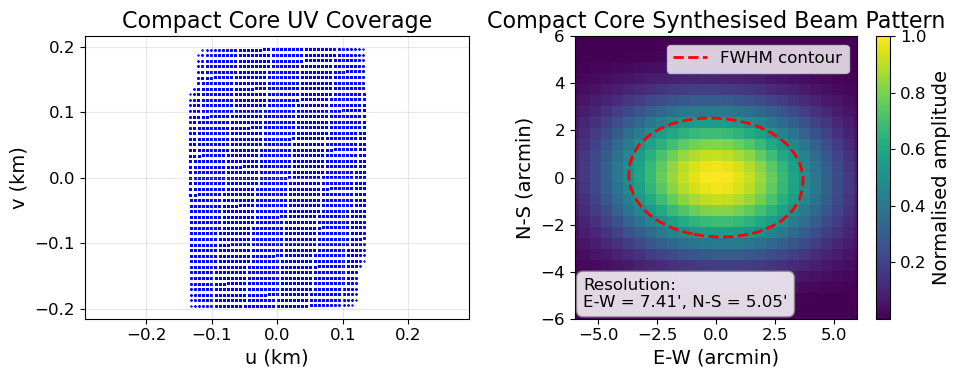

In [56]:
import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.titlesize": 16,
})
beam, l_arcmin, m_arcmin, eff_l_arcmin, eff_m_arcmin, relative_noise = compute_dirty_beam(uvd_compact, title=f"Compact Core",
    npix=256, freq_hz=FREQ_HZ, image_extent_deg=1, weighting="natural", zoom_extent=10, plot_beam=False)

zoom_extent = 6
extent = (
    float(l_arcmin[0]),
    float(l_arcmin[-1]),
    float(m_arcmin[0]),
    float(m_arcmin[-1]),
)

u_km = uvd_compact.uvw_array[:, 0] / 1e3
v_km = uvd_compact.uvw_array[:, 1] / 1e3

fig, (ax_uv, ax_beam) = plt.subplots(1, 2, figsize=(10, 4))

# Beam subplot
im = ax_beam.imshow(beam, origin="lower", extent=extent, cmap="viridis")
ax_beam.contour(
    beam,
    levels=[0.5],
    colors="red",
    linewidths=2.0,
    linestyles="--",
    extent=extent,
)
ax_beam.plot([], [], color="red", linestyle="--", linewidth=2, label="FWHM contour")
ax_beam.legend(loc="upper right")
fig.colorbar(im, ax=ax_beam, label="Normalised amplitude")
info = (
    f"Resolution:\nE-W = {eff_l_arcmin:.2f}', N-S = {eff_m_arcmin:.2f}'"
)
ax_beam.text(0.03, 0.03, info, transform=ax_beam.transAxes, ha="left", va="bottom",
        fontsize=12, bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                                alpha=0.85, edgecolor="gray"))

ax_beam.set_xlim(-zoom_extent, zoom_extent)
ax_beam.set_ylim(-zoom_extent, zoom_extent)
ax_beam.set_xlabel("E-W (arcmin)")
ax_beam.set_ylabel("N-S (arcmin)")
ax_beam.set_title("Compact Core Synthesised Beam Pattern")

# UV coverage subplot
ax_uv.scatter(u_km, v_km, s=0.2, alpha=0.25, color="blue")
ax_uv.scatter(-u_km, -v_km, s=0.2, alpha=0.25, color="blue")
ax_uv.set_xlabel("u (km)")
ax_uv.set_ylabel("v (km)")
ax_uv.set_title("Compact Core UV Coverage")
ax_uv.axis("equal")
ax_uv.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../../thesis/plots/ext_chord/uv_coverage_and_beam.png", dpi=300)
plt.show()

Unknown polarization basis -- assuming linearly polarized (x/y) feeds for Telescope.feed_array.
Parameter feed_array, feed_angle, and mount_type must be set together. Unsetting optional parameters.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.
Recalculating uvw_array without adjusting visibility phases -- this can introduce significant errors if used incorrectly.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.


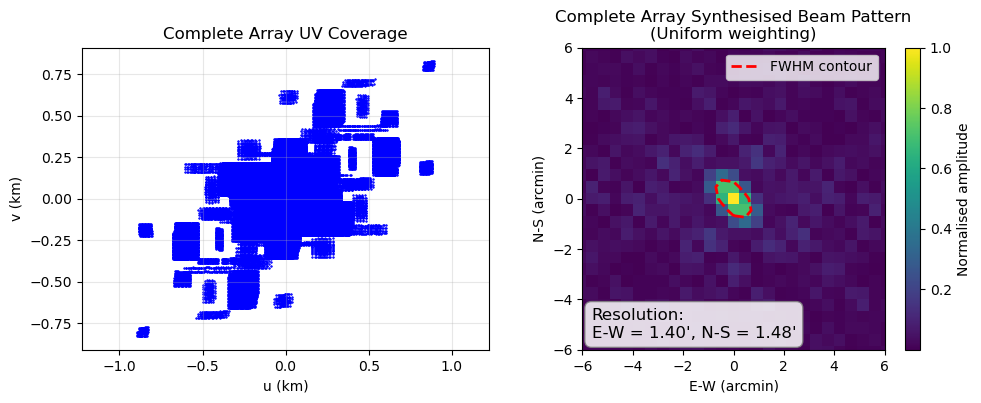

In [8]:
uvd_complete    = setup_uvdata(complete,    drao_loc, freq_hz=FREQ_HZ, n_times=10)

beam, l_arcmin, m_arcmin, eff_l_arcmin, eff_m_arcmin, relative_noise = compute_dirty_beam(uvd_complete, title=f"Complete Array",
    npix=256, freq_hz=FREQ_HZ, image_extent_deg=1, weighting="uniform", zoom_extent=10, plot_beam=False)

zoom_extent = 6
extent = (
    float(l_arcmin[0]),
    float(l_arcmin[-1]),
    float(m_arcmin[0]),
    float(m_arcmin[-1]),
)

u_km = uvd_complete.uvw_array[:, 0] / 1e3
v_km = uvd_complete.uvw_array[:, 1] / 1e3

fig, (ax_uv, ax_beam) = plt.subplots(1, 2, figsize=(10, 4))

# Beam subplot
im = ax_beam.imshow(beam, origin="lower", extent=extent, cmap="viridis")
ax_beam.contour(
    beam,
    levels=[0.5],
    colors="red",
    linewidths=2.0,
    linestyles="--",
    extent=extent,
)
ax_beam.plot([], [], color="red", linestyle="--", linewidth=2, label="FWHM contour")
ax_beam.legend(loc="upper right")
fig.colorbar(im, ax=ax_beam, label="Normalised amplitude")
info = (
    f"Resolution:\nE-W = {eff_l_arcmin:.2f}', N-S = {eff_m_arcmin:.2f}'"
)
ax_beam.text(0.03, 0.03, info, transform=ax_beam.transAxes, ha="left", va="bottom",
        fontsize=12, bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                                alpha=0.85, edgecolor="gray"))

ax_beam.set_xlim(-zoom_extent, zoom_extent)
ax_beam.set_ylim(-zoom_extent, zoom_extent)
ax_beam.set_xlabel("E-W (arcmin)")
ax_beam.set_ylabel("N-S (arcmin)")
ax_beam.set_title("Complete Array Synthesised Beam Pattern\n(Uniform weighting)")

# UV coverage subplot
ax_uv.scatter(u_km, v_km, s=0.2, alpha=0.25, color="blue")
ax_uv.scatter(-u_km, -v_km, s=0.2, alpha=0.25, color="blue")
ax_uv.set_xlabel("u (km)")
ax_uv.set_ylabel("v (km)")
ax_uv.set_title("Complete Array UV Coverage")
ax_uv.axis("equal")
ax_uv.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../../thesis/plots/ext_chord/uv_coverage_and_beam_complete.png", dpi=300)
plt.show()

## Plot of Core plus A

In [48]:
uvd_compact_A = setup_uvdata(compact_A, drao_loc, freq_hz=FREQ_HZ, n_times=10)

Unknown polarization basis -- assuming linearly polarized (x/y) feeds for Telescope.feed_array.
Parameter feed_array, feed_angle, and mount_type must be set together. Unsetting optional parameters.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.
Recalculating uvw_array without adjusting visibility phases -- this can introduce significant errors if used incorrectly.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


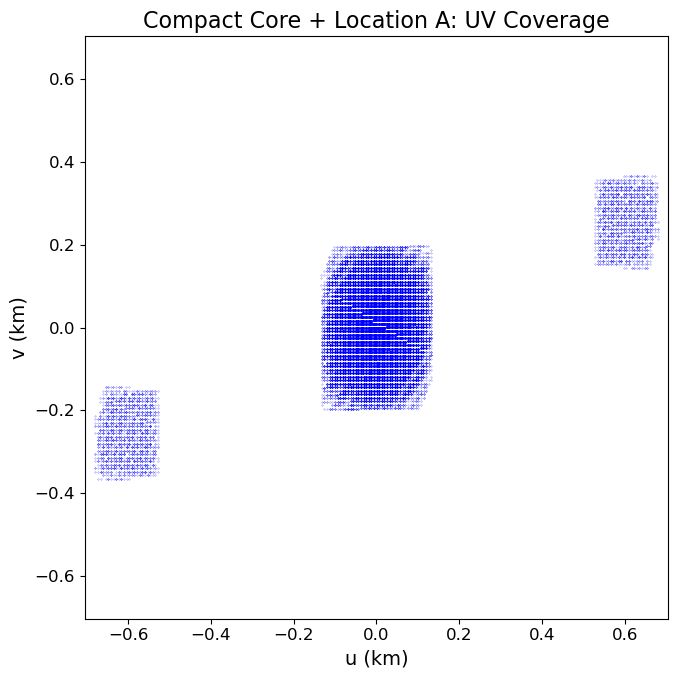

In [49]:
from matplotlib.ticker import MultipleLocator
import matplotlib.pyplot as plt

u_km = uvd_compact_A.uvw_array[:, 0]/1e3
v_km = uvd_compact_A.uvw_array[:, 1]/1e3

fig, ax = plt.subplots(figsize=(7, 7))

u_km_sampled = u_km[::50]
v_km_sampled = v_km[::50]
ax.scatter(u_km_sampled, v_km_sampled, s=0.05, color="blue", alpha=0.7)
ax.scatter(-u_km_sampled, -v_km_sampled, s=0.05, color="blue", alpha=0.7)

ax.set_xlabel("u (km)")
ax.set_ylabel("v (km)")
ax.set_title("Compact Core + Location A: UV Coverage")
ax.axis("equal")

plt.xlim(-0.7, 0.7)
plt.ylim(-0.7, 0.7)
plt.tight_layout()
plt.show()

Sampled 11 robust values in 9 bisections, total iterations: 9


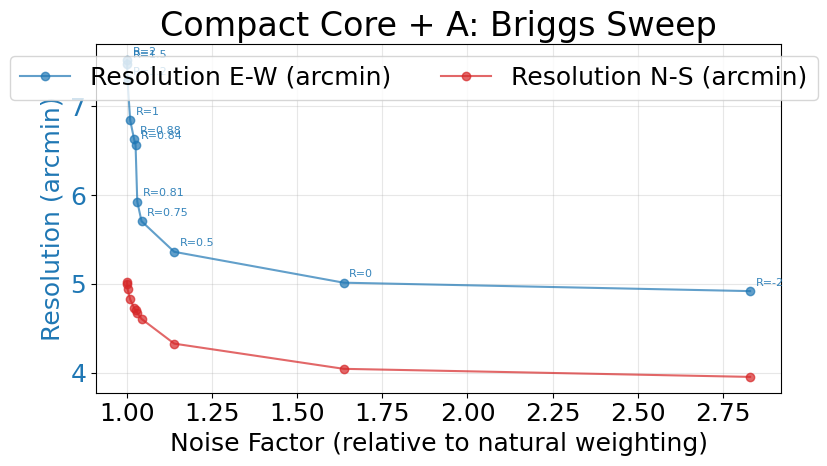

In [52]:
r_arr, nf_arr, eff_l_arr, eff_m_arr = adaptive_briggs_sweep(
    uvd_compact_A, tol=0.5, npix=256, image_extent_deg=1, r_hi=2, r_lo=-2
)

plot_briggs_values("Compact Core + A: Briggs Sweep", r_arr, nf_arr, eff_l_arr, eff_m_arr)

In [18]:
FREQ_HZ

900000000.0

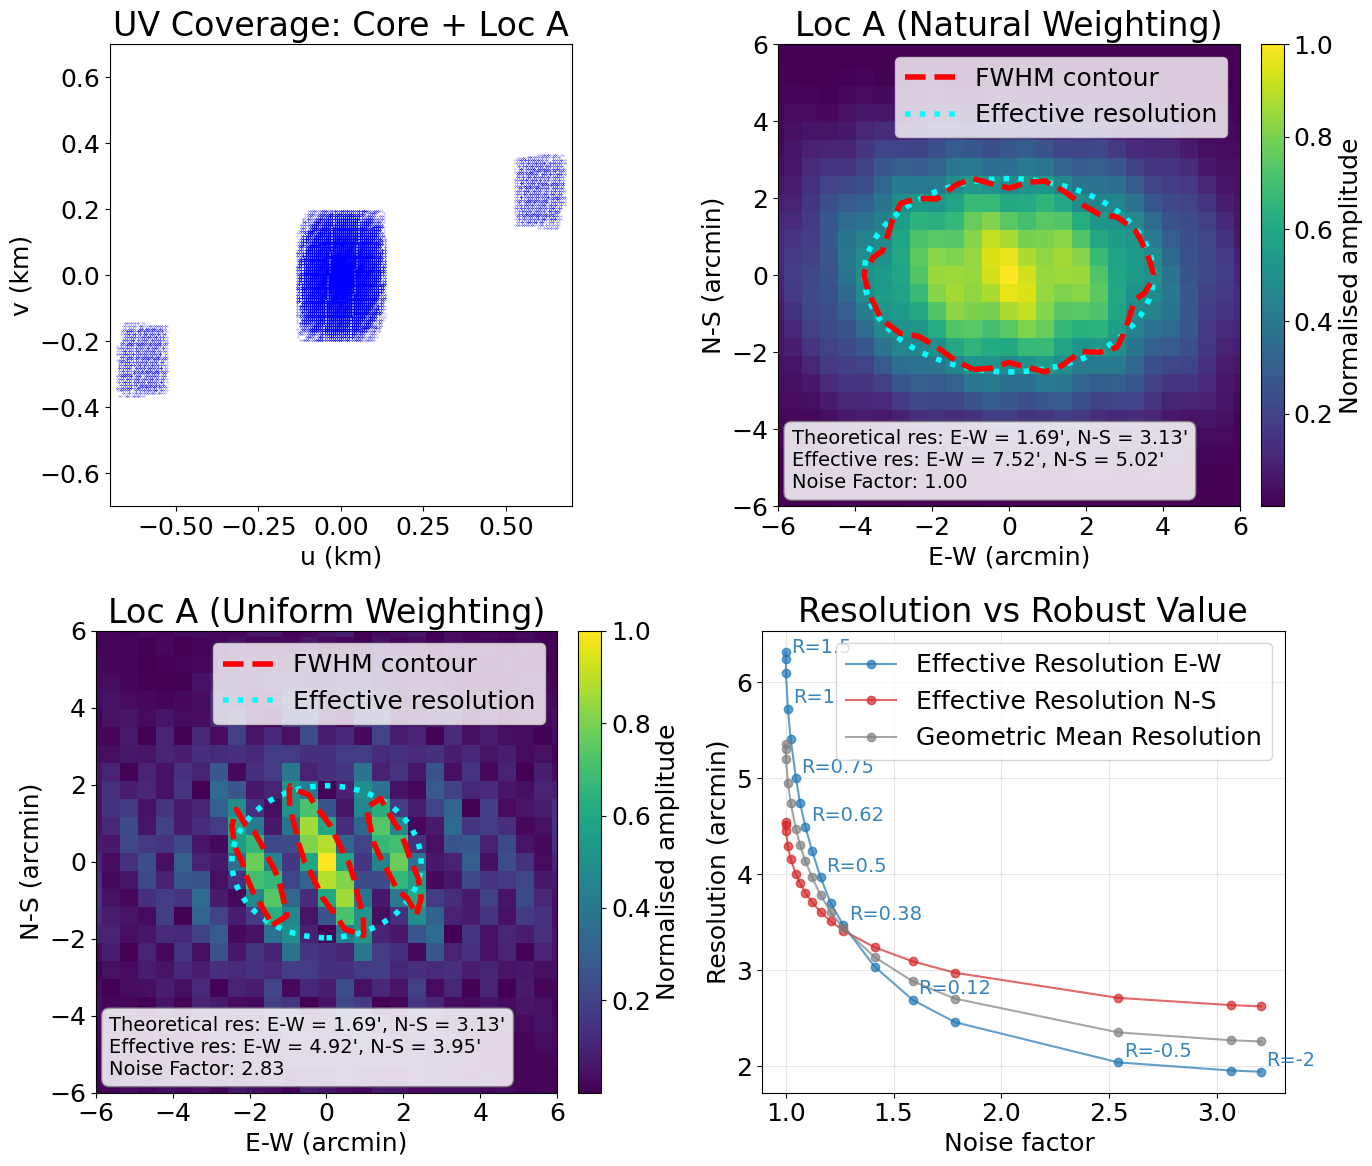

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# --- shared params (tweak freely) ---
NPIX = 256
IMAGE_EXTENT_DEG = 1
ZOOM_EXTENT = 6         # arcmin half-window for the beam panels
lambda_m = 3e8 / FREQ_HZ

def theoretical_res_arcmin(uvd):
    """Theoretical 1/u, 1/v resolution in arcmin (matches compute_dirty_beam)."""
    u_lam = np.concatenate([uvd.uvw_array[:, 0], -uvd.uvw_array[:, 0]]) / lambda_m
    v_lam = np.concatenate([uvd.uvw_array[:, 1], -uvd.uvw_array[:, 1]]) / lambda_m
    max_u, max_v = np.abs(u_lam).max(), np.abs(v_lam).max()
    theta_l = (1.0 / max_u) * (180 / np.pi * 60) if max_u > 0 else np.nan
    theta_m = (1.0 / max_v) * (180 / np.pi * 60) if max_v > 0 else np.nan
    return theta_l, theta_m

def plot_beam_panel(ax, uvd, weighting, robust=None, title=""):
    beam, l_arcmin, m_arcmin, eff_l, eff_m, rel_noise = compute_dirty_beam(
        uvd, npix=NPIX, freq_hz=FREQ_HZ, image_extent_deg=IMAGE_EXTENT_DEG,
        weighting=weighting, robust=robust, plot_beam=False,
    )
    extent = (float(l_arcmin[0]), float(l_arcmin[-1]),
              float(m_arcmin[0]), float(m_arcmin[-1]))
    theta_l, theta_m = theoretical_res_arcmin(uvd)

    im = ax.imshow(beam, origin="lower", extent=extent, cmap="viridis")
    fig.colorbar(im, ax=ax, label="Normalised amplitude", fraction=0.046, pad=0.04)

    # Standard FWHM: half-max contour of the dirty beam
    ax.contour(beam, levels=[0.5], colors="red", linewidths=4.0,
               linestyles="--", extent=extent)
    ax.plot([], [], color="red", linestyle="--", linewidth=4, label="FWHM contour")

    # Effective FWHM: ellipse from the fitted-Gaussian FWHM (eff_l, eff_m)
    ax.add_patch(Ellipse((0, 0), width=eff_l, height=eff_m,
                         edgecolor="cyan", facecolor="none",
                         linewidth=4.0, linestyle=":"))
    ax.plot([], [], color="cyan", linestyle=":", linewidth=4, label="Effective resolution")
    ax.legend(loc="upper right")

    ax.set_xlim(-ZOOM_EXTENT, ZOOM_EXTENT)
    ax.set_ylim(-ZOOM_EXTENT, ZOOM_EXTENT)
    ax.set_xlabel("E-W (arcmin)")
    ax.set_ylabel("N-S (arcmin)")
    ax.set_title(title)

    info = (
        f"Theoretical res: E-W = {theta_l:.2f}', N-S = {theta_m:.2f}'\n"
        f"Effective res: E-W = {eff_l:.2f}', N-S = {eff_m:.2f}'\n"
        f"Noise Factor: {rel_noise:.2f}"
    )
    ax.text(0.03, 0.03, info, transform=ax.transAxes, ha="left", va="bottom",
            fontsize=14, bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                                  alpha=0.85, edgecolor="gray"))

# ============================ Figure ============================
plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 24,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
    "figure.titlesize": 26,
})
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
ax_uv, ax_nat = axes[0]
ax_uni, ax_briggs = axes[1]

# Top-left: UV coverage
u_km = uvd_compact_A.uvw_array[:, 0] / 1e3
v_km = uvd_compact_A.uvw_array[:, 1] / 1e3
ax_uv.scatter(u_km[::50], v_km[::50], s=0.05, color="blue", alpha=0.7)
ax_uv.scatter(-u_km[::50], -v_km[::50], s=0.05, color="blue", alpha=0.7)
ax_uv.set_xlabel("u (km)")
ax_uv.set_ylabel("v (km)")
ax_uv.set_title("UV Coverage: Core + Loc A")
ax_uv.set_aspect("equal")
ax_uv.set_xlim(-0.7, 0.7)
ax_uv.set_ylim(-0.7, 0.7)

# Top-right: natural weighting beam
plot_beam_panel(ax_nat, uvd_compact_A, "natural",
                title="Loc A (Natural Weighting)")

# Bottom-left: uniform weighting beam
plot_beam_panel(ax_uni, uvd_compact_A, "uniform",
                title="Loc A (Uniform Weighting)")

c_l, c_m = "tab:blue", "tab:red"
ax_briggs.plot(nf_arr, eff_l_arr, "o-", color=c_l, alpha=0.7, label="Effective Resolution E-W")
ax_briggs.plot(nf_arr, eff_m_arr, "o-", color=c_m, alpha=0.7, label="Effective Resolution N-S")
ax_briggs.plot(nf_arr, np.sqrt(eff_l_arr * eff_m_arr), "o-", color="grey", alpha=0.7, label="Geometric Mean Resolution")

# Annotate each Briggs robust value
for nf_i, res_l_i, r_i in zip(nf_arr[::2], eff_l_arr[::2], r_arr[::2]):
    ax_briggs.annotate(f"R={r_i:.2g}", (nf_i, res_l_i),
                       textcoords="offset points", xytext=(4, 4),
                       fontsize=14, color=c_l, alpha=0.9)

ax_briggs.set_xlabel("Noise factor ")
ax_briggs.set_ylabel("Resolution (arcmin)")
ax_briggs.set_title("Resolution vs Robust Value")
ax_briggs.legend(loc="upper right")
ax_briggs.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../../thesis/plots/ext_chord/loc_A_cov_and_beam.png", dpi=300)
plt.show()


## Get combined metrics and plots for all combinations

In [35]:
import os
import time
import itertools
import traceback
import numpy as np
import matplotlib.pyplot as plt

NPIX = 256
IMAGE_EXTENT_DEG = 1
ZOOM_EXTENT = 6         # arcmin half-window for the beam panels
lambda_m = 3e8 / FREQ_HZ

# Named extension locations (the compact core is always included).
# Note: A2 is an alternate placement of site A, so the A + A2 pairing is not
# physically meaningful -- remove it from `combos` below if you want to skip it.
named_locations = [
    ("A",  location_A),
    ("A2", location_A2),
    ("B",  location_B),
    ("C",  location_C),
    ("D",  location_D),
    ("E",  location_E),
    ("F",  location_F),
    ("G",  location_G),
]
loc_names = [name for name, _ in named_locations]
loc_index = {name: i for i, name in enumerate(loc_names)}
N = len(named_locations)

BASE_DIR = "results"
N_TIMES = 10        # UV coverage is set by geometry; a few integrations is plenty
                    # for gridding the beam and keeps memory/disk low.
os.makedirs(BASE_DIR, exist_ok=True)

# Pair-plot matrices. Symmetric N x N grids per weighting: the diagonal [i, i]
# is location i on its own (compact + i), the off-diagonal [i, j] is the pair
# (compact + i + j). We record E-W and N-S effective resolution and the noise
# factor for each weighting.
WEIGHTINGS = ["natural", "briggs0", "uniform"]
eff_l_mat = {w: np.full((N, N), np.nan) for w in WEIGHTINGS}
eff_m_mat = {w: np.full((N, N), np.nan) for w in WEIGHTINGS}
nf_mat = {w: np.full((N, N), np.nan) for w in WEIGHTINGS}

def _record(weighting, i, j, eff_l, eff_m, nf):
    eff_l_mat[weighting][i, j] = eff_l_mat[weighting][j, i] = eff_l
    eff_m_mat[weighting][i, j] = eff_m_mat[weighting][j, i] = eff_m
    nf_mat[weighting][i, j] = nf_mat[weighting][j, i] = nf

# Every 1-location and 2-location combination with the compact core.
combos = (list(itertools.combinations(named_locations, 1))
          + list(itertools.combinations(named_locations, 2)))

failures = []
t_start = time.time()

for n, combo in enumerate(combos, 1):
    names = [name for name, _ in combo]
    locs = [loc for _, loc in combo]
    idx = [loc_index[n_] for n_ in names]
    i, j = (idx[0], idx[0]) if len(idx) == 1 else (idx[0], idx[1])
    tag = "compact_" + "_".join(names)            # e.g. compact_A, compact_A_B
    title = "Compact Core + " + " + ".join(names)
    out_dir = os.path.join(BASE_DIR, tag)
    os.makedirs(out_dir, exist_ok=True)
    print(f"\n[{n}/{len(combos)}] === {tag} ===", flush=True)
    t0 = time.time()

    try:
        # Combined array -> visibilities. Only the uvw coordinates are used
        # downstream, so save those (float32) rather than the full UVData.
        array = combine_locations(compact, *locs)
        uvd = setup_uvdata(array, drao_loc, n_times=N_TIMES, freq_hz=FREQ_HZ)
        np.save(os.path.join(out_dir, "uvw.npy"), uvd.uvw_array.astype(np.float32))
        print(f"    built array + uvw ({array.shape[0]} dishes)", flush=True)

        common = dict(npix=NPIX, freq_hz=FREQ_HZ, image_extent_deg=IMAGE_EXTENT_DEG,
                      plot_beam=True, show=False)

        # Beam plots: natural, Briggs R=0, uniform. Saved without displaying;
        # the effective resolution and noise factor from each are recorded.
        *_, eff_l, eff_m, nf = compute_dirty_beam(
            uvd, title=title, weighting="natural",
            save_path=os.path.join(out_dir, "beam_natural.png"), **common)
        _record("natural", i, j, eff_l, eff_m, nf)
        print(f"    natural : res = {eff_l:.2f}' x {eff_m:.2f}',  nf = {nf:.2f}", flush=True)

        *_, eff_l, eff_m, nf = compute_dirty_beam(
            uvd, title=title, weighting="briggs", robust=0,
            save_path=os.path.join(out_dir, "beam_briggs0.png"), **common)
        _record("briggs0", i, j, eff_l, eff_m, nf)
        print(f"    briggs0 : res = {eff_l:.2f}' x {eff_m:.2f}',  nf = {nf:.2f}", flush=True)

        *_, eff_l, eff_m, nf = compute_dirty_beam(
            uvd, title=title, weighting="uniform",
            save_path=os.path.join(out_dir, "beam_uniform.png"), **common)
        _record("uniform", i, j, eff_l, eff_m, nf)
        print(f"    uniform : res = {eff_l:.2f}' x {eff_m:.2f}',  nf = {nf:.2f}", flush=True)

        # Briggs sweep: save the arrays and the trade-off plot.
        r_arr, nf_arr, eff_l_arr, eff_m_arr = adaptive_briggs_sweep(
            uvd, tol=0.5, npix=NPIX, image_extent_deg=IMAGE_EXTENT_DEG, r_hi=2, r_lo=-2
        )
        np.savez(os.path.join(out_dir, "briggs_sweep.npz"),
                 r=r_arr, noise_factor=nf_arr, eff_l=eff_l_arr, eff_m=eff_m_arr)
        plot_briggs_values(f"{title}: Briggs Sweep", r_arr, nf_arr, eff_l_arr, eff_m_arr,
                           show=False, save_path=os.path.join(out_dir, "briggs_sweep.png"))

        del uvd, array          # free the large arrays before the next config
        print(f"    done in {time.time() - t0:.1f}s", flush=True)

    except Exception as exc:
        failures.append((tag, repr(exc)))
        print(f"    !! FAILED: {exc}", flush=True)
        traceback.print_exc()
        continue

# Consolidated resolution pair-plot data: per weighting, the E-W and N-S
# effective resolution matrices plus the beam-area-equivalent resolution
# (geometric mean sqrt(eff_l * eff_m)). The diagonal holds single-location
# results.
res_summary = {"locations": np.array(loc_names)}
for w in WEIGHTINGS:
    res_summary[f"{w}_eff_l"] = eff_l_mat[w]
    res_summary[f"{w}_eff_m"] = eff_m_mat[w]
    res_summary[f"{w}_area"] = np.sqrt(eff_l_mat[w] * eff_m_mat[w])
np.savez(os.path.join(BASE_DIR, "pairplot_resolution.npz"), **res_summary)

# Consolidated noise-factor pair-plot data (relative to natural weighting).
nf_summary = {"locations": np.array(loc_names)}
for w in WEIGHTINGS:
    nf_summary[f"{w}_noise"] = nf_mat[w]
np.savez(os.path.join(BASE_DIR, "pairplot_noise.npz"), **nf_summary)

print(f"\nDone in {time.time() - t_start:.1f}s. "
      f"{len(combos) - len(failures)}/{len(combos)} permutations succeeded.")
if failures:
    print(f"{len(failures)} failed:")
    for tag, err in failures:
        print(f"  - {tag}: {err}")
print(f"Resolution matrices -> '{os.path.join(BASE_DIR, 'pairplot_resolution.npz')}'")
print(f"Noise-factor matrices -> '{os.path.join(BASE_DIR, 'pairplot_noise.npz')}'")



[1/36] === compact_A ===


Unknown polarization basis -- assuming linearly polarized (x/y) feeds for Telescope.feed_array.
Parameter feed_array, feed_angle, and mount_type must be set together. Unsetting optional parameters.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.
Recalculating uvw_array without adjusting visibility phases -- this can introduce significant errors if used incorrectly.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.


    built array + uvw (528 dishes)
Saved dirty beam plot to 'results/compact_A/beam_natural.png'
    natural : res = 7.52' x 5.02',  nf = 1.00
Saved dirty beam plot to 'results/compact_A/beam_briggs0.png'
    briggs0 : res = 5.01' x 4.04',  nf = 1.64
Saved dirty beam plot to 'results/compact_A/beam_uniform.png'
    uniform : res = 4.92' x 3.95',  nf = 2.83
Sampled 11 robust values in 9 bisections, total iterations: 9
Saved Briggs values plot to 'results/compact_A/briggs_sweep.png'
    done in 11.0s

[2/36] === compact_A2 ===


Unknown polarization basis -- assuming linearly polarized (x/y) feeds for Telescope.feed_array.
Parameter feed_array, feed_angle, and mount_type must be set together. Unsetting optional parameters.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.
Recalculating uvw_array without adjusting visibility phases -- this can introduce significant errors if used incorrectly.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.


    built array + uvw (528 dishes)
Saved dirty beam plot to 'results/compact_A2/beam_natural.png'
    natural : res = 7.42' x 5.01',  nf = 1.00
Saved dirty beam plot to 'results/compact_A2/beam_briggs0.png'
    briggs0 : res = 4.95' x 3.98',  nf = 1.75
Saved dirty beam plot to 'results/compact_A2/beam_uniform.png'
    uniform : res = 4.81' x 3.42',  nf = 3.62
Sampled 13 robust values in 11 bisections, total iterations: 11
Saved Briggs values plot to 'results/compact_A2/briggs_sweep.png'
    done in 11.6s

[3/36] === compact_B ===


...

    built array + uvw (544 dishes)
Saved dirty beam plot to 'results/compact_E_F/beam_natural.png'
    natural : res = 7.22' x 4.55',  nf = 1.00
Saved dirty beam plot to 'results/compact_E_F/beam_briggs0.png'
    briggs0 : res = 3.08' x 2.84',  nf = 1.74
Saved dirty beam plot to 'results/compact_E_F/beam_uniform.png'
    uniform : res = 2.54' x 2.39',  nf = 3.55
Sampled 17 robust values in 15 bisections, total iterations: 15
Saved Briggs values plot to 'results/compact_E_F/briggs_sweep.png'
    done in 13.1s

[35/36] === compact_E_G ===


Unknown polarization basis -- assuming linearly polarized (x/y) feeds for Telescope.feed_array.
Parameter feed_array, feed_angle, and mount_type must be set together. Unsetting optional parameters.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.
Recalculating uvw_array without adjusting visibility phases -- this can introduce significant errors if used incorrectly.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.


    built array + uvw (536 dishes)
Saved dirty beam plot to 'results/compact_E_G/beam_natural.png'
    natural : res = 7.39' x 4.58',  nf = 1.00
Saved dirty beam plot to 'results/compact_E_G/beam_briggs0.png'
    briggs0 : res = 4.87' x 2.23',  nf = 1.79
Saved dirty beam plot to 'results/compact_E_G/beam_uniform.png'
    uniform : res = 4.46' x 2.08',  nf = 3.79
Sampled 10 robust values in 8 bisections, total iterations: 8
Saved Briggs values plot to 'results/compact_E_G/briggs_sweep.png'
    done in 10.5s

[36/36] === compact_F_G ===


Unknown polarization basis -- assuming linearly polarized (x/y) feeds for Telescope.feed_array.
Parameter feed_array, feed_angle, and mount_type must be set together. Unsetting optional parameters.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.
Recalculating uvw_array without adjusting visibility phases -- this can introduce significant errors if used incorrectly.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.


    built array + uvw (536 dishes)
Saved dirty beam plot to 'results/compact_F_G/beam_natural.png'
    natural : res = 6.94' x 4.96',  nf = 1.00
Saved dirty beam plot to 'results/compact_F_G/beam_briggs0.png'
    briggs0 : res = 2.86' x 4.18',  nf = 1.78
Saved dirty beam plot to 'results/compact_F_G/beam_uniform.png'
    uniform : res = 2.52' x 4.15',  nf = 3.56
Sampled 15 robust values in 13 bisections, total iterations: 13
Saved Briggs values plot to 'results/compact_F_G/briggs_sweep.png'
    done in 12.0s

Done in 419.3s. 36/36 permutations succeeded.
Resolution matrices -> 'results/pairplot_resolution.npz'
Noise-factor matrices -> 'results/pairplot_noise.npz'


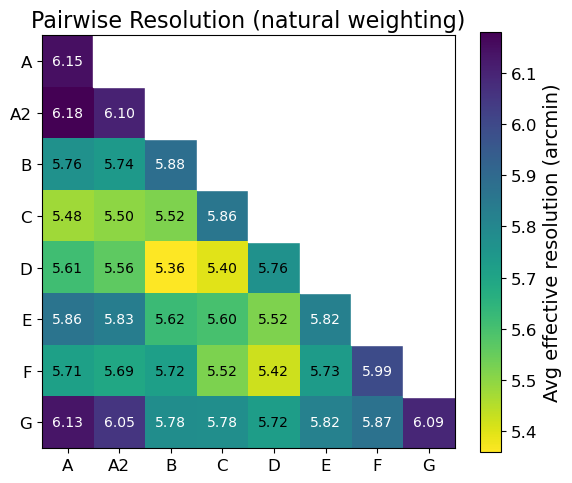

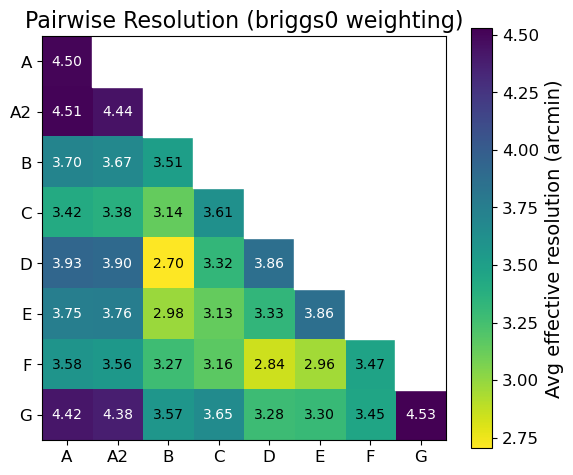

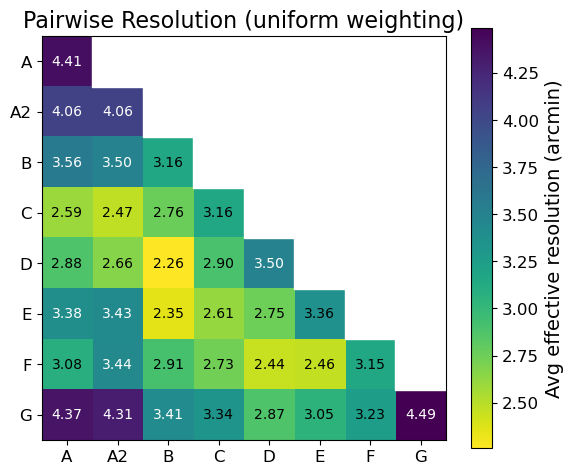

In [41]:
d = np.load("results/pairplot_resolution.npz")
names = d["locations"]
N = len(names)

for w in ["natural", "briggs0", "uniform"]:
    mat = d[f"{w}_area"]
    
    fig, ax = plt.subplots(figsize=(6, 5))
    
    # Mask upper triangle (keep lower triangle + diagonal)
    mask = np.triu(np.ones((N, N), dtype=bool), k=1)
    masked_mat = np.ma.array(mat, mask=mask)
    
    im = ax.imshow(masked_mat, origin="upper", cmap="viridis_r")
    ax.set_xticks(range(N)); ax.set_xticklabels(names)
    ax.set_yticks(range(N)); ax.set_yticklabels(names)
    fig.colorbar(im, label="Avg effective resolution (arcmin)")
    ax.set_title(f"Pairwise Resolution ({w} weighting)")
    
    # Annotate lower triangle + diagonal
    vmin, vmax = masked_mat.min(), masked_mat.max()
    for i in range(N):
        for j in range(i + 1):
            val = mat[i, j]
            # Choose text colour for contrast
            text_color = "black" if val < (vmin + vmax) / 2 else "white"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=10, color=text_color)
    
    # Hide upper triangle ticks/spines visually by drawing white patches
    for i in range(N):
        for j in range(i + 1, N):
            ax.add_patch(plt.Rectangle(
                (j - 0.5, i - 0.5), 1, 1,
                color="white", zorder=2
            ))
    
    plt.tight_layout()
    plt.savefig(f"../../thesis/plots/ext_chord/pairplot_resolution_{w}.png", dpi=150)
    plt.show()


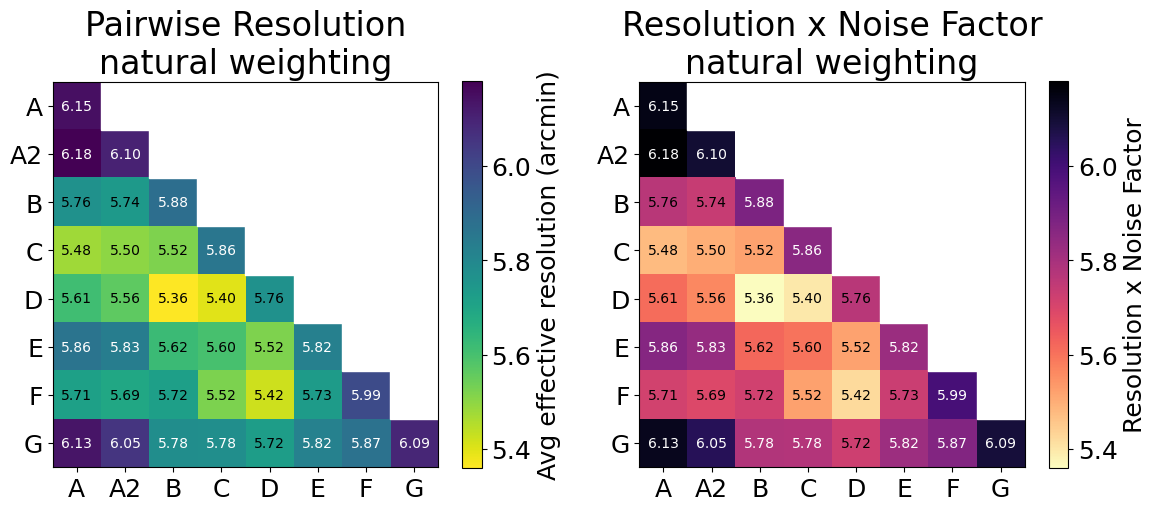

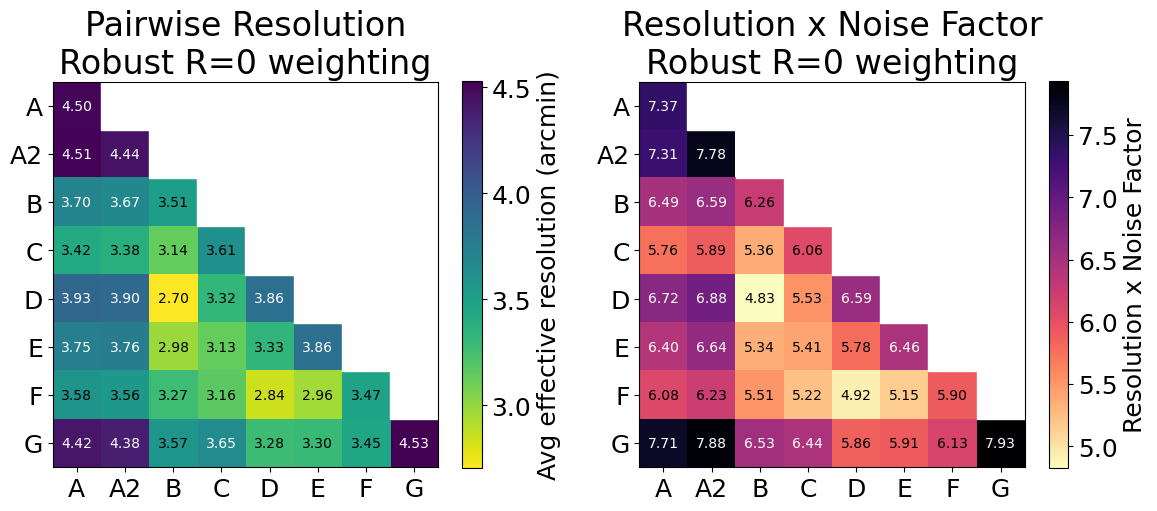

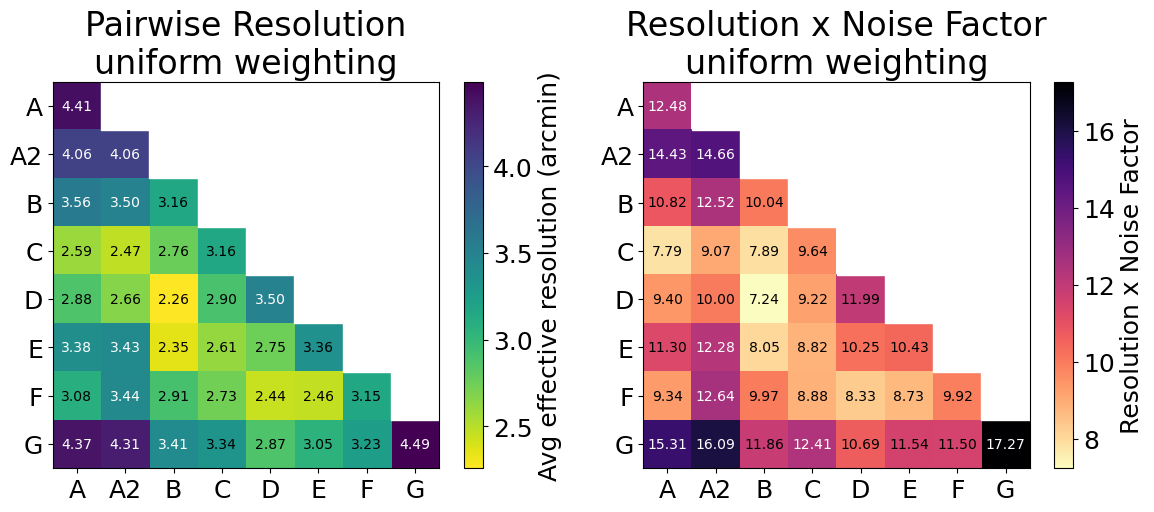

In [83]:
from matplotlib.patches import Rectangle

d_res = np.load("results/pairplot_resolution.npz")
d_nf = np.load("results/pairplot_noise.npz")

names = d_res["locations"]
N = len(names)

weighting_labels = {
    "natural": "natural",
    "briggs0": "Robust R=0",
    "uniform": "uniform",
}

for w in ["natural", "briggs0", "uniform"]:
    res_mat = d_res[f"{w}_area"]
    nf_mat = d_nf[f"{w}_noise"]
    w_label = weighting_labels[w]

    fig, (ax_res, ax_nf) = plt.subplots(1, 2, figsize=(12, 5))

    # Mask upper triangle (keep lower triangle + diagonal)
    mask = np.triu(np.ones((N, N), dtype=bool), k=1)

    for ax, mat, cmap, cbar_label, title in [
        (ax_res, res_mat, "viridis_r", "Avg effective resolution (arcmin)", f"Pairwise Resolution\n{w_label} weighting"),
        (ax_nf,  nf_mat*res_mat,  "magma_r",   "Resolution x Noise Factor",                     f"Resolution x Noise Factor\n{w_label} weighting"),
    ]:
        masked_mat = np.ma.array(mat, mask=mask)
        im = ax.imshow(masked_mat, origin="upper", cmap=cmap)

        ax.set_xticks(range(N))
        ax.set_xticklabels(names)
        ax.set_yticks(range(N))
        ax.set_yticklabels(names)
        ax.set_title(title)
        fig.colorbar(im, ax=ax, label=cbar_label)

        vals = mat[~mask]
        vmin, vmax = np.min(vals), np.max(vals)
        mid = 0.5 * (vmin + vmax)

        for i in range(N):
            for j in range(i + 1):
                val = mat[i, j]
                text_color = "black" if val < mid else "white"
                ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                        fontsize=10, color=text_color)

        for i in range(N):
            for j in range(i + 1, N):
                ax.add_patch(Rectangle((j - 0.5, i - 0.5), 1, 1, color="white", zorder=2))

    plt.tight_layout()
    plt.savefig(f"../../thesis/plots/ext_chord/pairplot_resolution_noise_{w}.png", dpi=150)
    plt.show()

## B and D beams plotted

In [58]:
uvd_compact_B = setup_uvdata(compact_B, drao_loc, freq_hz=FREQ_HZ, n_times=10)
uvd_compact_D = setup_uvdata(compact_D, drao_loc, freq_hz=FREQ_HZ, n_times=10)
uvd_compact_BD = setup_uvdata(combine_locations(compact, location_B, location_D), drao_loc, freq_hz=FREQ_HZ, n_times=10)

Unknown polarization basis -- assuming linearly polarized (x/y) feeds for Telescope.feed_array.
Parameter feed_array, feed_angle, and mount_type must be set together. Unsetting optional parameters.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.
Recalculating uvw_array without adjusting visibility phases -- this can introduce significant errors if used incorrectly.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.
Unknown polarization basis -- assuming linearly polarized (x/y) feeds for Telescope.feed_array.
Parameter feed_array, feed_angle, and mount_type must be set together. Unsetting optional parameters.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.
Recalculating uvw_array without adjusting visibility phases -- this can introduce significant errors if used incorrectly.
itrs position v

In [59]:
r_arr, nf_arr, eff_l_arr, eff_m_arr = adaptive_briggs_sweep(
    uvd_compact_BD, tol=0.5, npix=256, image_extent_deg=1, r_hi=2, r_lo=-2
)

Sampled 18 robust values in 16 bisections, total iterations: 16


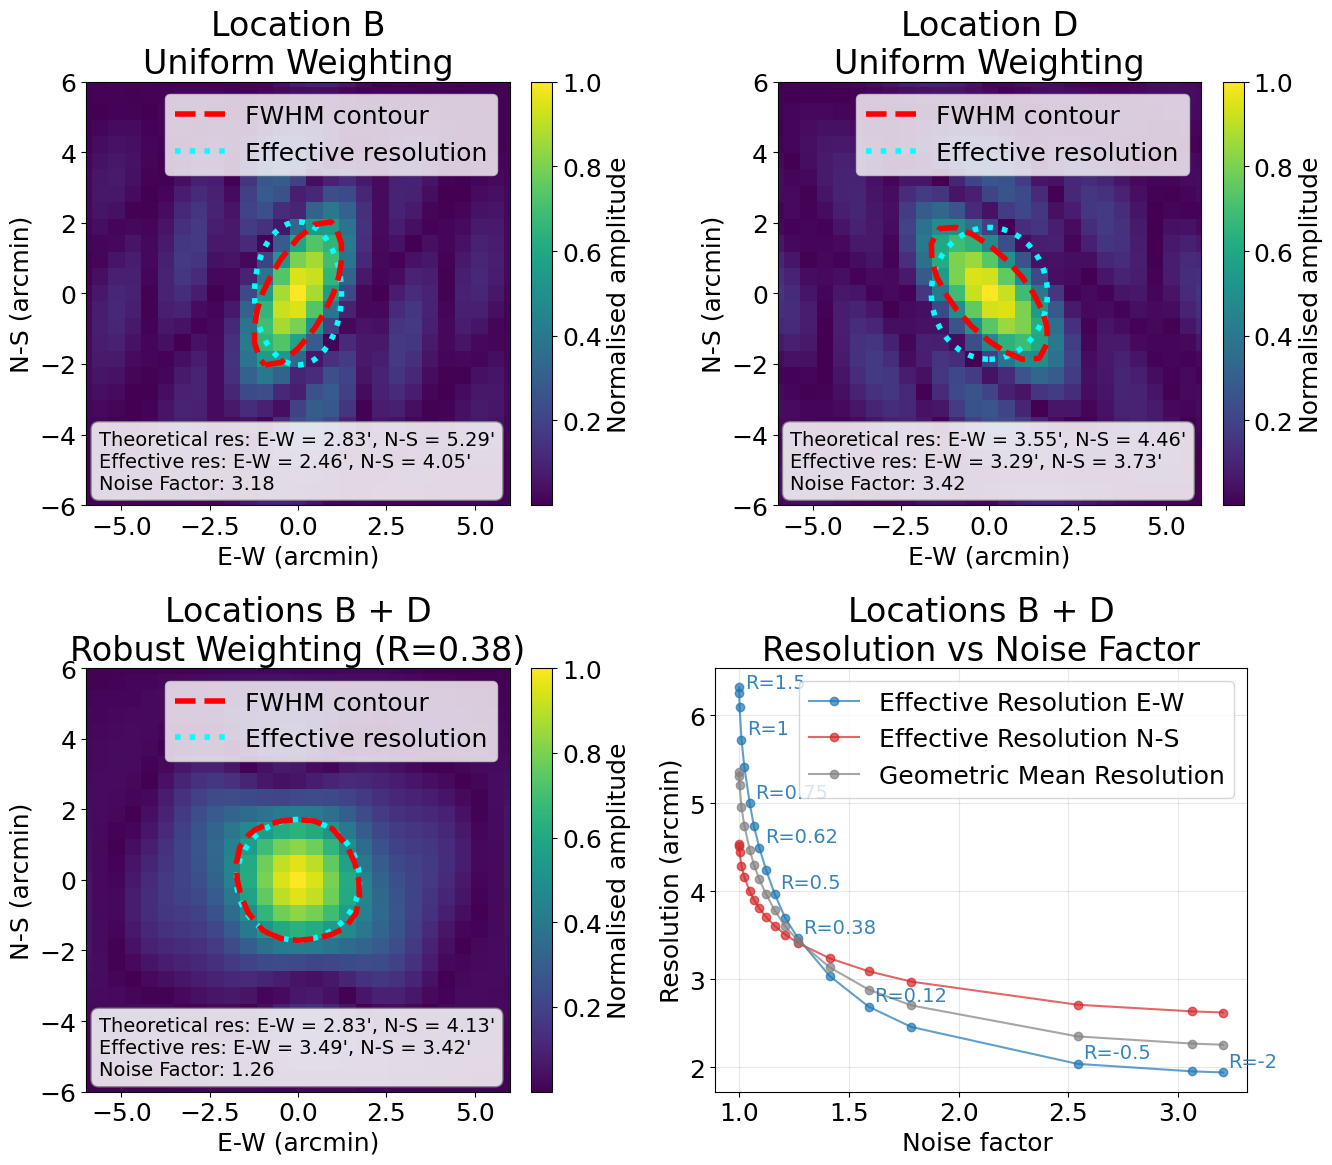

In [72]:
# ============================ Figure ============================
plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 24,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
    "figure.titlesize": 26,
})
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
ax_beam_B, ax_beam_D = axes[0]
ax_beam_BD, ax_briggs = axes[1]

# Top-left: uniform weighting beam
plot_beam_panel(ax_beam_B, uvd_compact_B, "uniform",
                title="Location B\nUniform Weighting")

# Top-right: uniform weighting beam
plot_beam_panel(ax_beam_D, uvd_compact_D, "uniform",
                title="Location D\nUniform Weighting")

# Bottom-left: Briggs weighting beam
plot_beam_panel(ax_beam_BD, uvd_compact_BD, "briggs", robust=0.38,
                title="Locations B + D\nRobust Weighting (R=0.38)")

c_l, c_m = "tab:blue", "tab:red"
ax_briggs.plot(nf_arr, eff_l_arr, "o-", color=c_l, alpha=0.7, label="Effective Resolution E-W")
ax_briggs.plot(nf_arr, eff_m_arr, "o-", color=c_m, alpha=0.7, label="Effective Resolution N-S")
ax_briggs.plot(nf_arr, np.sqrt(eff_l_arr * eff_m_arr), "o-", color="grey", alpha=0.7, label="Geometric Mean Resolution")

# Annotate each Briggs robust value
for nf_i, res_l_i, r_i in zip(nf_arr[::2], eff_l_arr[::2], r_arr[::2]):
    ax_briggs.annotate(f"R={r_i:.2g}", (nf_i, res_l_i),
                       textcoords="offset points", xytext=(4, 4),
                       fontsize=14, color=c_l, alpha=0.9)

ax_briggs.set_xlabel("Noise factor ")
ax_briggs.set_ylabel("Resolution (arcmin)")
ax_briggs.set_title("Locations B + D\nResolution vs Noise Factor")
ax_briggs.legend(loc="upper right")
ax_briggs.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../../thesis/plots/ext_chord/loc_BD_beam_briggs.png", dpi=300)
plt.show()

## UV coverage of B, D and B+D

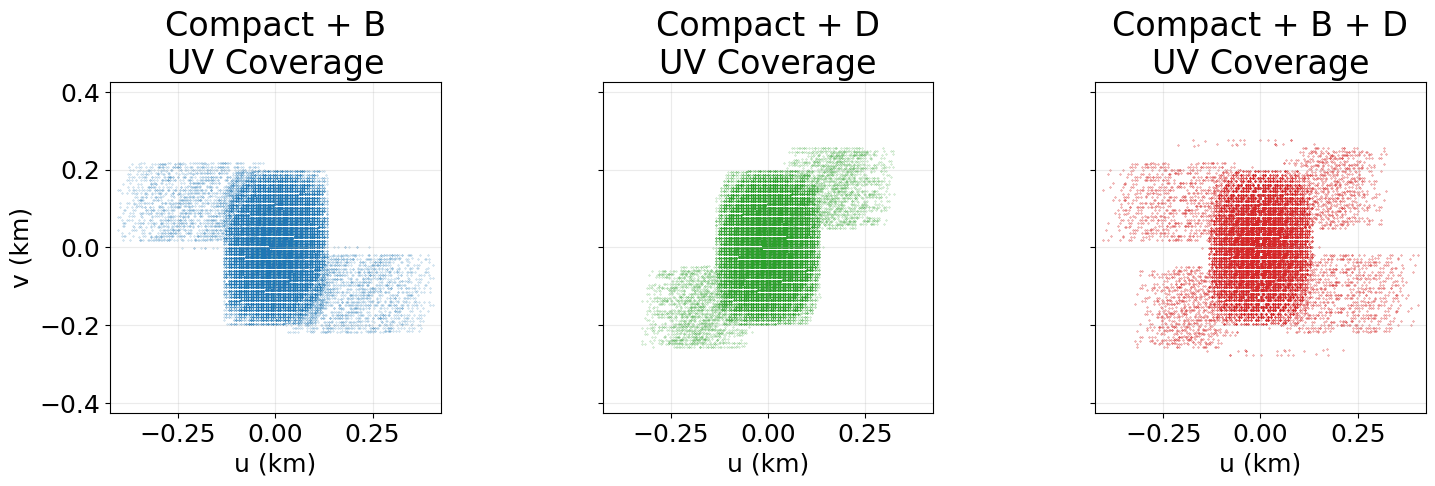

In [74]:
datasets = [
    ("Compact + B", uvd_compact_B, "tab:blue"),
    ("Compact + D", uvd_compact_D, "tab:green"),
    ("Compact + B + D", uvd_compact_BD, "tab:red"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)

# Set a common axis range from all three datasets
all_u = np.concatenate([ds.uvw_array[:, 0] for _, ds, _ in datasets]) / 1e3
all_v = np.concatenate([ds.uvw_array[:, 1] for _, ds, _ in datasets]) / 1e3
lim = 1.05 * max(np.max(np.abs(all_u)), np.max(np.abs(all_v)))

for ax, (title, uvd, color) in zip(axes, datasets):
    u_km = uvd.uvw_array[:, 0] / 1e3
    v_km = uvd.uvw_array[:, 1] / 1e3

    step = 50  # downsample for speed/clarity
    ax.scatter(u_km[::step],  v_km[::step],  s=0.06, alpha=0.6, color=color)
    ax.scatter(-u_km[::step], -v_km[::step], s=0.06, alpha=0.6, color=color)

    ax.set_title(f"{title}\nUV Coverage")
    ax.set_xlabel("u (km)")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel("v (km)")
for ax in axes:
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)

plt.tight_layout()
plt.savefig("../../thesis/plots/ext_chord/uv_coverage_B_D_BD.png", dpi=300)
plt.show()

## Dirty Beams — Compact Core + Location A

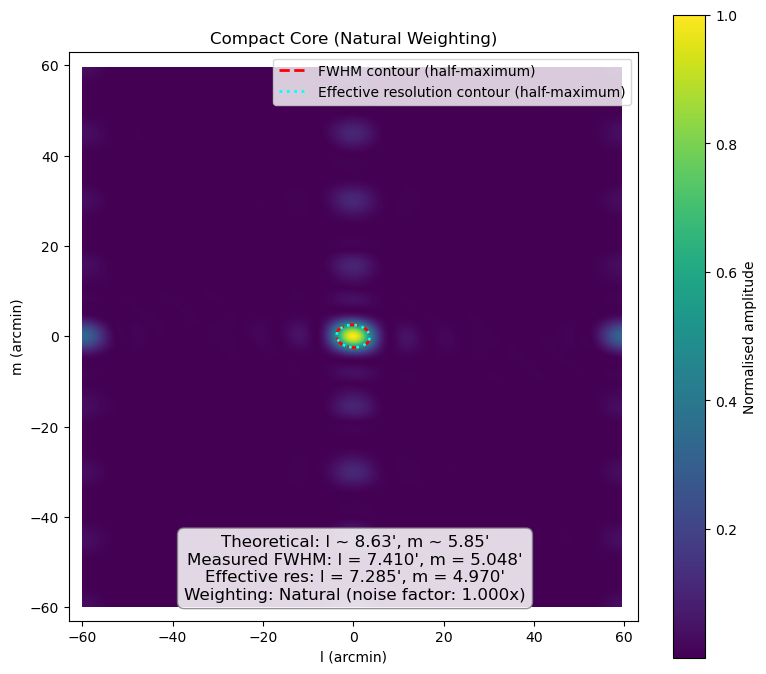

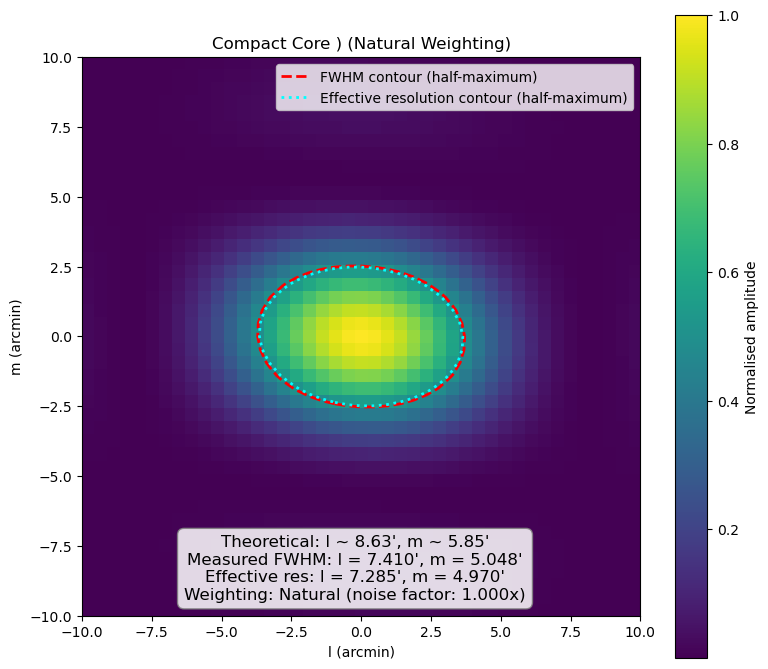

In [ ]:
for npix in [256]:
    compute_dirty_beam(uvd_compact, title=f"Compact Core",
                       npix=npix, freq_hz=FREQ_HZ, image_extent_deg=1, weighting="natural", zoom_extent=63)
    
    compute_dirty_beam(uvd_compact, title=f"Compact Core",
                       npix=npix, freq_hz=FREQ_HZ, image_extent_deg=1, weighting="natural", zoom_extent=10)


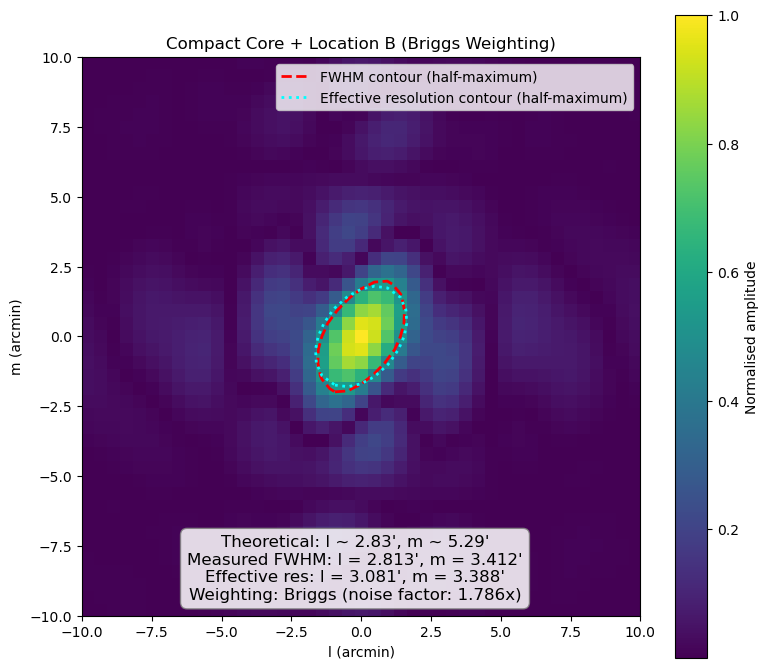

In [12]:
_ = compute_dirty_beam(uvd_compact_B, title=f"Compact Core + Location B",
                       npix=npix, freq_hz=FREQ_HZ, image_extent_deg=1, weighting="briggs", robust=0, zoom_extent=10)

## Noise factor, and effective resolution for Briggs weighting

Sampled 10 robust values in 8 bisections, total iterations: 8


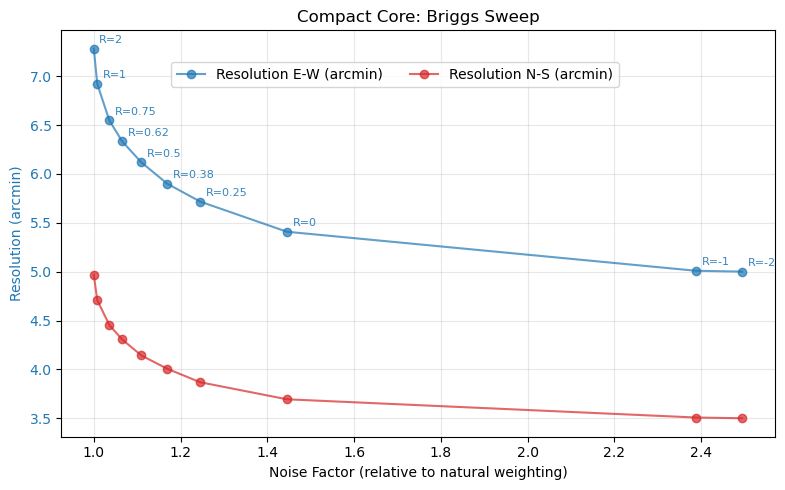

In [13]:
r_arr, nf_arr, eff_l_arr, eff_m_arr = adaptive_briggs_sweep(
    uvd_compact, tol=0.4, npix=256, image_extent_deg=1,
)

plot_briggs_values("Compact Core: Briggs Sweep", r_arr, nf_arr, eff_l_arr, eff_m_arr)


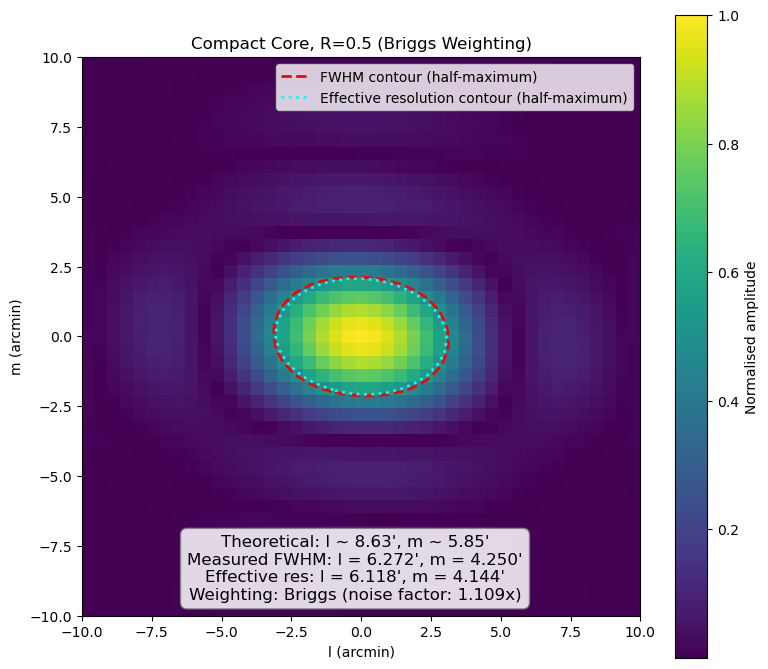

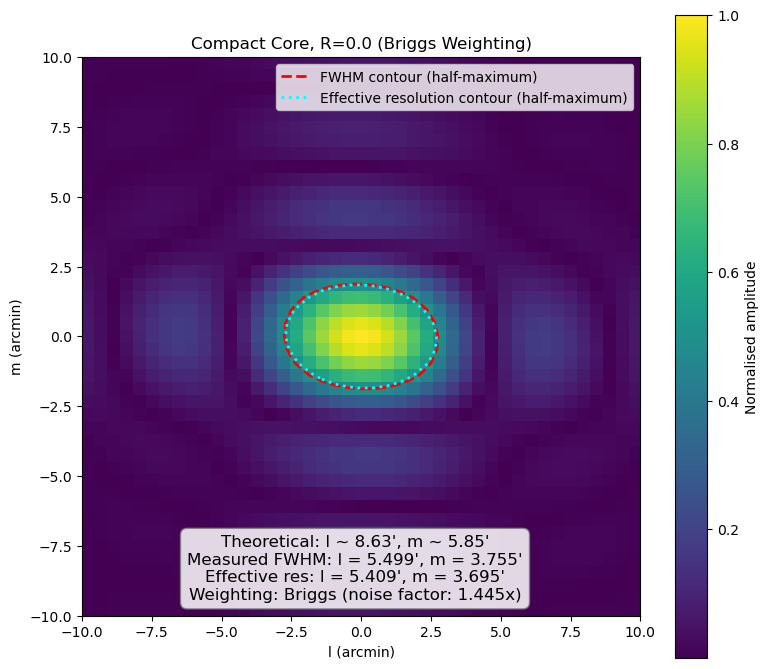

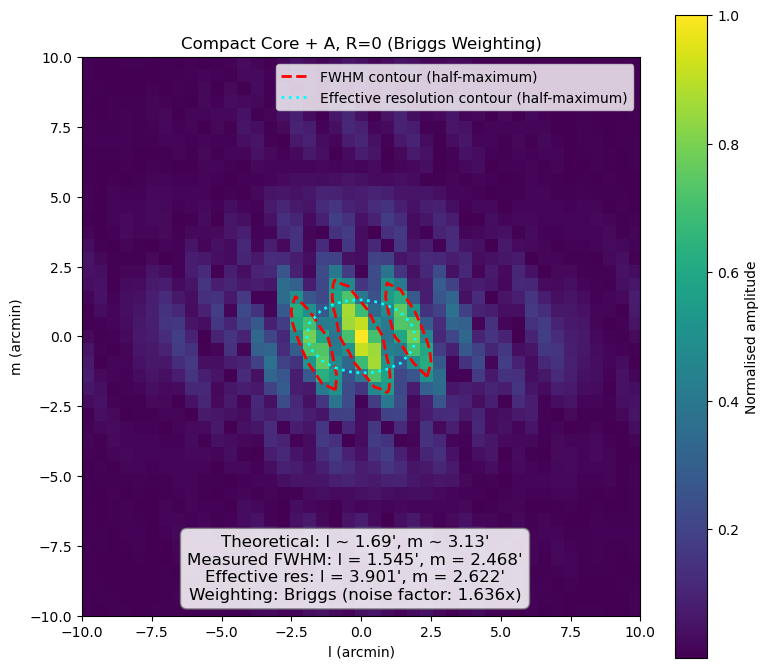

In [30]:
for R in [0.5, 0.0]:
    _ = compute_dirty_beam(uvd_compact, title=f"Compact Core, R={R}",
                    npix=npix, freq_hz=FREQ_HZ, image_extent_deg=1, robust = R, weighting="briggs", zoom_extent=10)
_ = compute_dirty_beam(uvd_compact_A, title=f"Compact Core + A, R={0}",
                    npix=npix, freq_hz=FREQ_HZ, image_extent_deg=1, robust = 0, weighting="briggs", zoom_extent=10)

## Compact + A

Sampled 18 robust values in 16 bisections, total iterations: 16


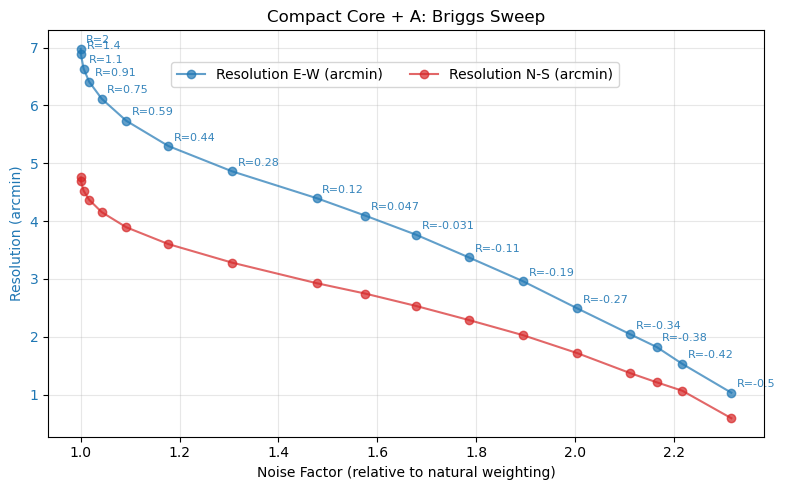

In [29]:
# uvd_compact_A  = setup_uvdata(compact_A,  drao_loc, freq_hz=FREQ_HZ)

r_arr, nf_arr, eff_l_arr, eff_m_arr = adaptive_briggs_sweep(
    uvd_compact_A, tol=0.5, npix=256, image_extent_deg=1, r_hi=2, r_lo=-0.5
)

plot_briggs_values("Compact Core + A: Briggs Sweep", r_arr, nf_arr, eff_l_arr, eff_m_arr)

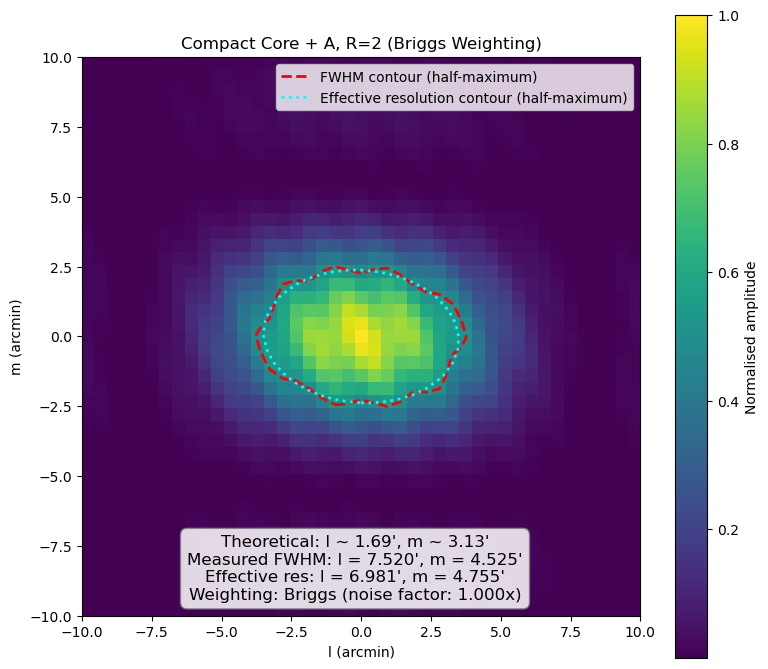

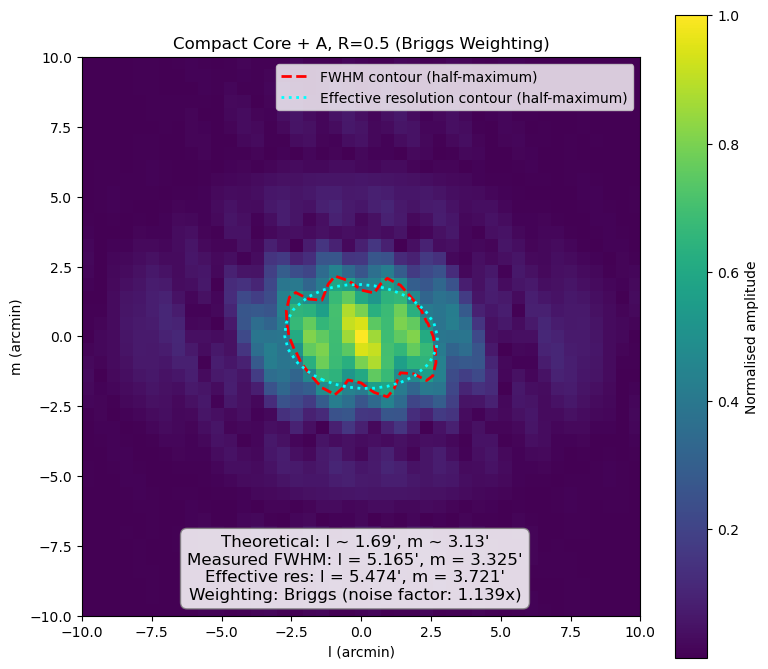

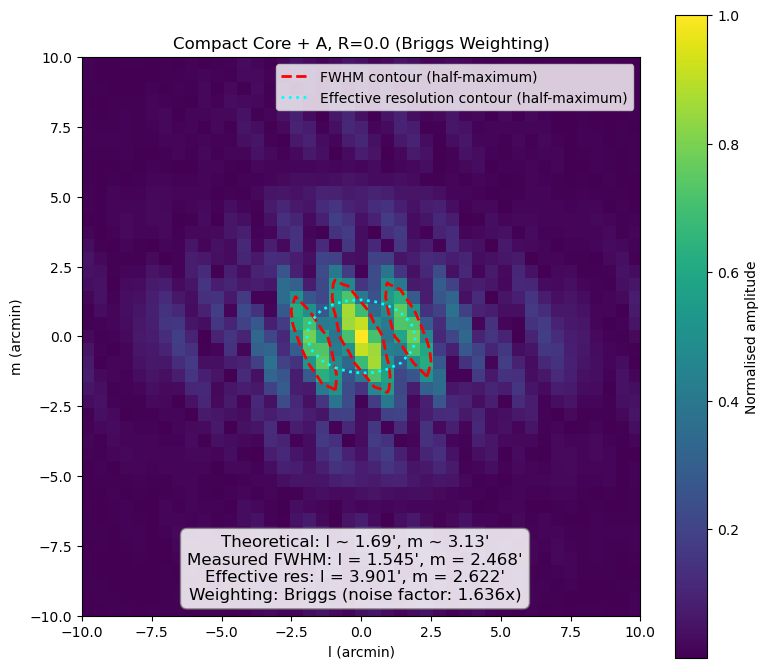

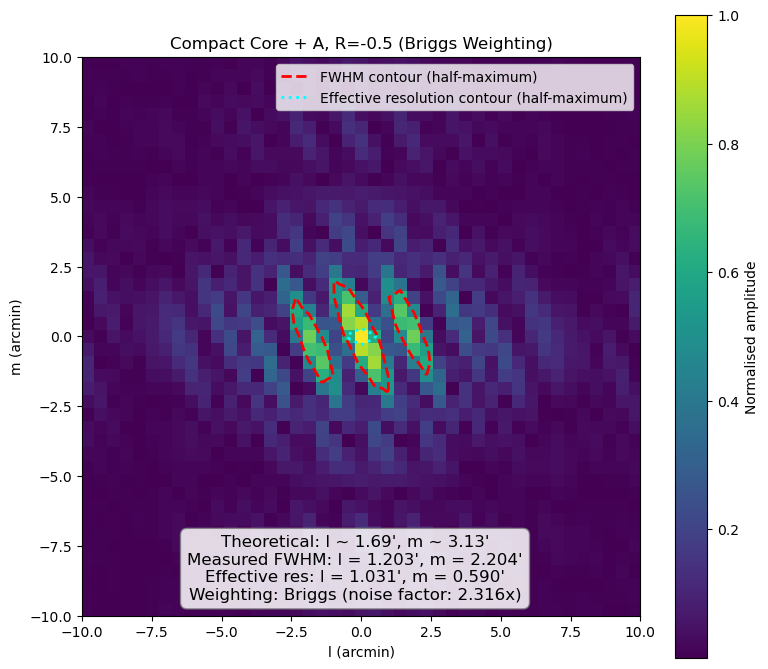

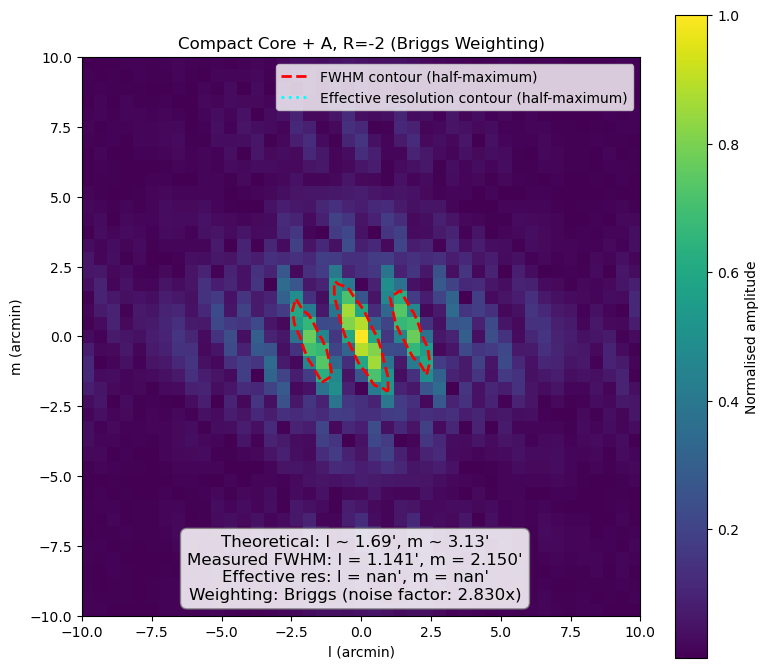

In [27]:
for R in [2, 0.5, 0.0, -0.5, -2]:
    _ = compute_dirty_beam(uvd_compact_A, title=f"Compact Core + A, R={R}",
                    npix=npix, freq_hz=FREQ_HZ, image_extent_deg=1, robust = R, weighting="briggs", zoom_extent=10)


## Compact + B

Sampled 17 robust values in 15 bisections, total iterations: 15


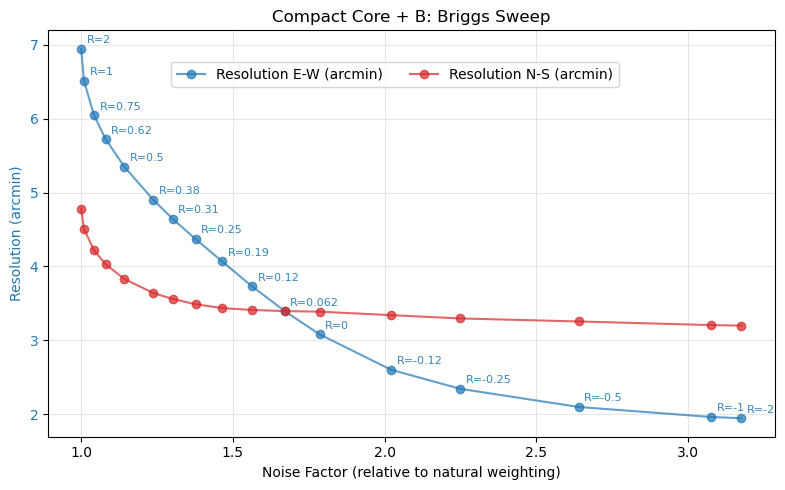

In [17]:
r_arr, nf_arr, eff_l_arr, eff_m_arr = adaptive_briggs_sweep(
    uvd_compact_B, tol=0.5, npix=256, image_extent_deg=1,
)

plot_briggs_values("Compact Core + B: Briggs Sweep", r_arr, nf_arr, eff_l_arr, eff_m_arr)

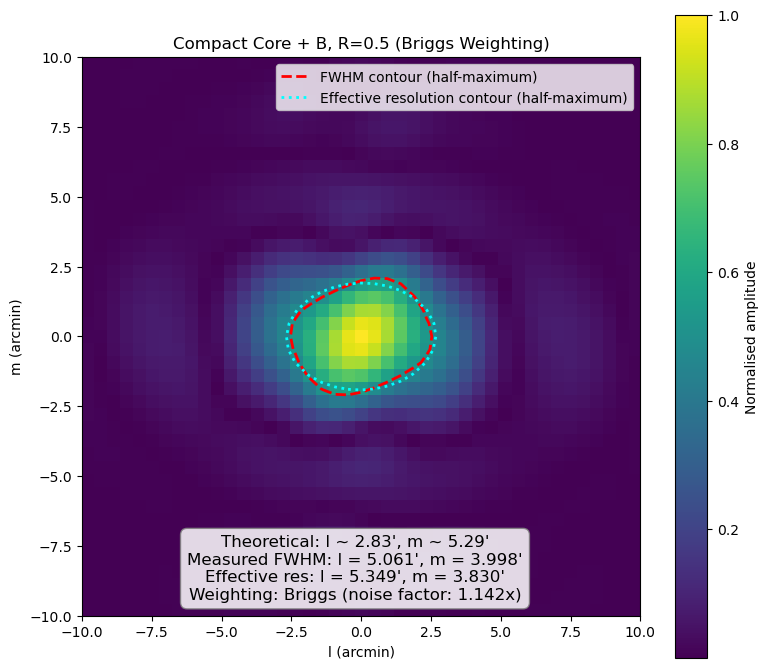

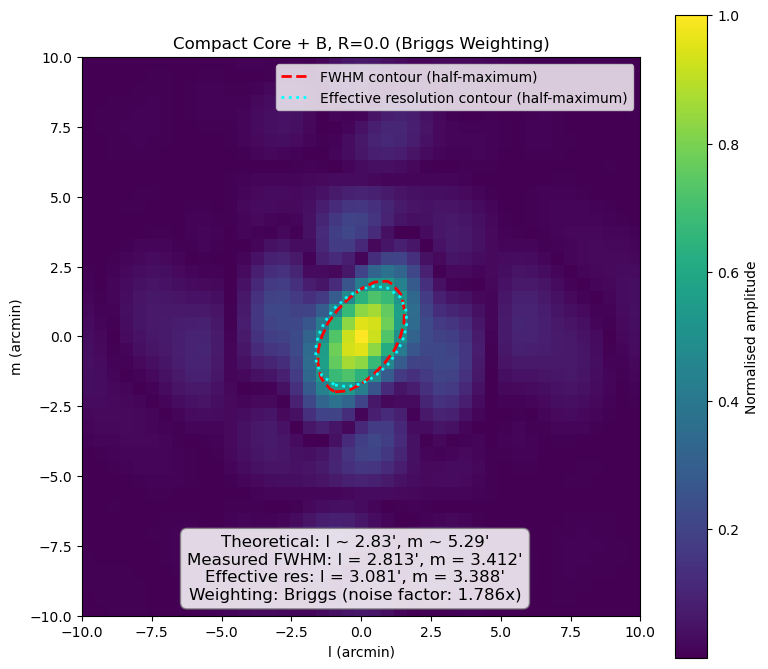

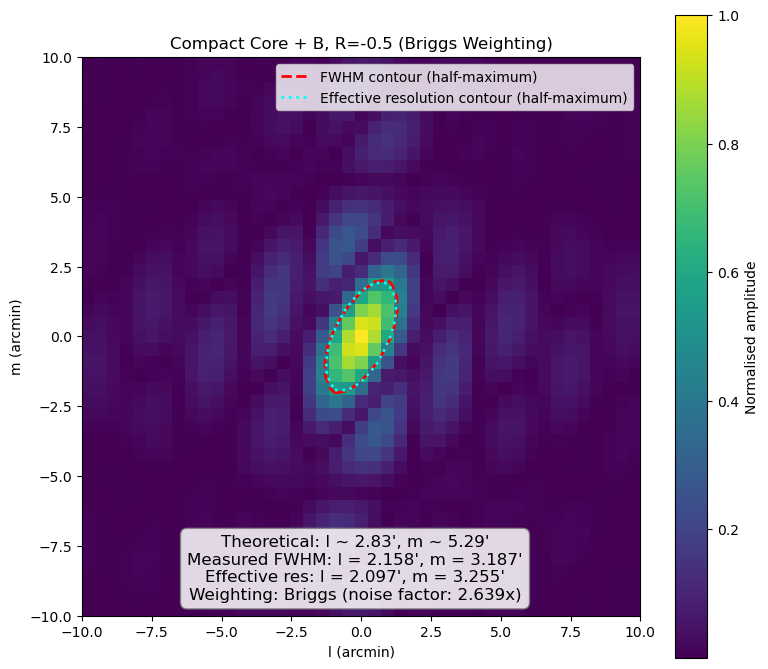

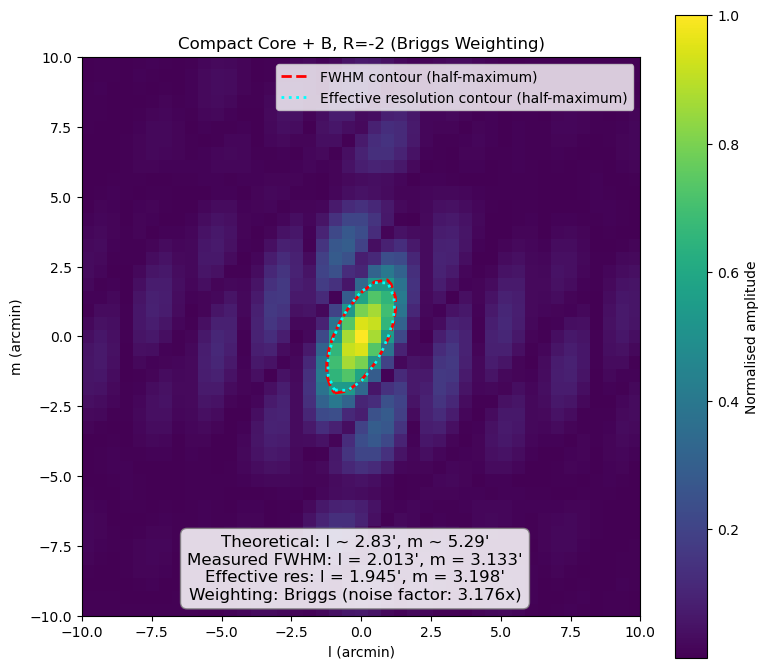

In [18]:
for R in [0.5, 0.0, -0.5, -2]:
    _ = compute_dirty_beam(uvd_compact_B, title=f"Compact Core + B, R={R}",
                    npix=npix, freq_hz=FREQ_HZ, image_extent_deg=1, robust = R, weighting="briggs", zoom_extent=10)

## Compact + C

Unknown polarization basis -- assuming linearly polarized (x/y) feeds for Telescope.feed_array.
Parameter feed_array, feed_angle, and mount_type must be set together. Unsetting optional parameters.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.
Recalculating uvw_array without adjusting visibility phases -- this can introduce significant errors if used incorrectly.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.


Sampled 15 robust values in 13 bisections, total iterations: 13


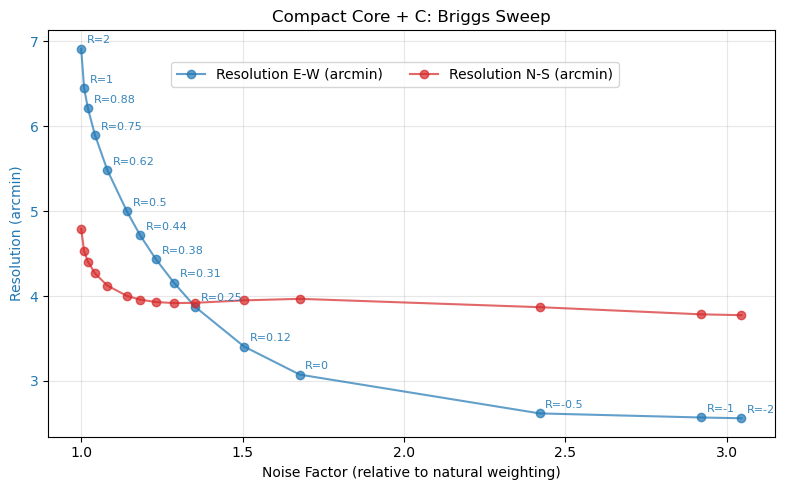

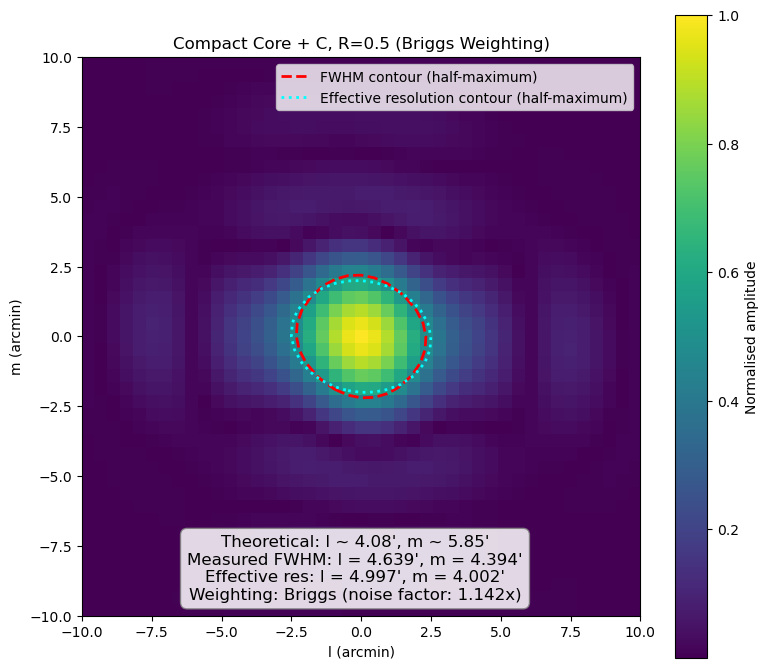

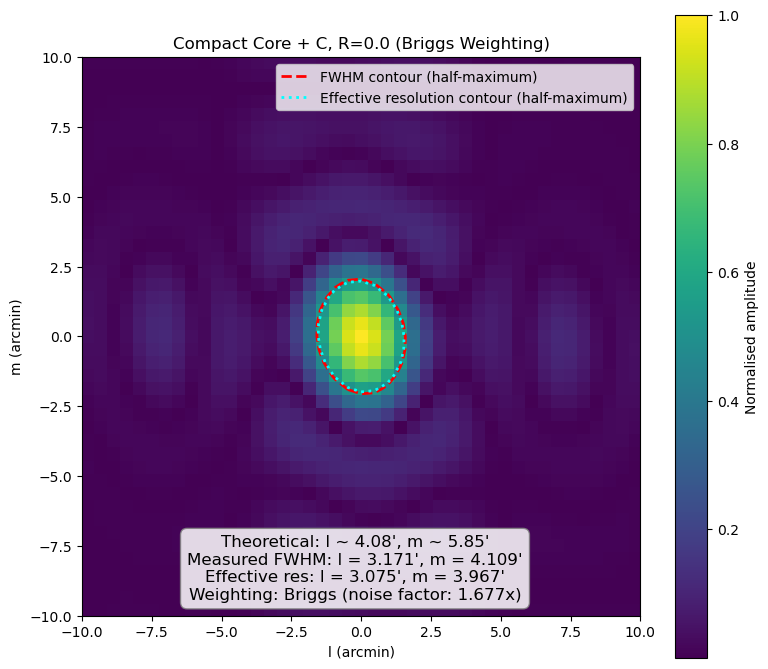

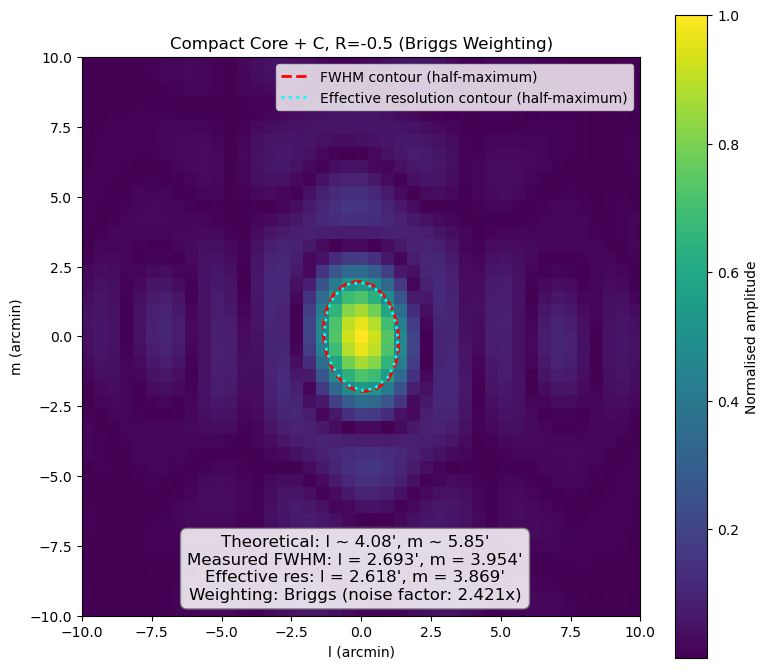

In [24]:
uvd_compact_C = setup_uvdata(compact_C, drao_loc, freq_hz=FREQ_HZ)

r_arr, nf_arr, eff_l_arr, eff_m_arr = adaptive_briggs_sweep(
    uvd_compact_C, tol=0.5, npix=256, image_extent_deg=1,
)

plot_briggs_values("Compact Core + C: Briggs Sweep", r_arr, nf_arr, eff_l_arr, eff_m_arr)

for R in [0.5, 0.0, -0.5]:
    _ = compute_dirty_beam(uvd_compact_C, title=f"Compact Core + C, R={R}",
                    npix=npix, freq_hz=FREQ_HZ, image_extent_deg=1, robust = R, weighting="briggs", zoom_extent=10)

## Compact + D

Unknown polarization basis -- assuming linearly polarized (x/y) feeds for Telescope.feed_array.
Parameter feed_array, feed_angle, and mount_type must be set together. Unsetting optional parameters.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.
Recalculating uvw_array without adjusting visibility phases -- this can introduce significant errors if used incorrectly.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.


Sampled 16 robust values in 14 bisections, total iterations: 14


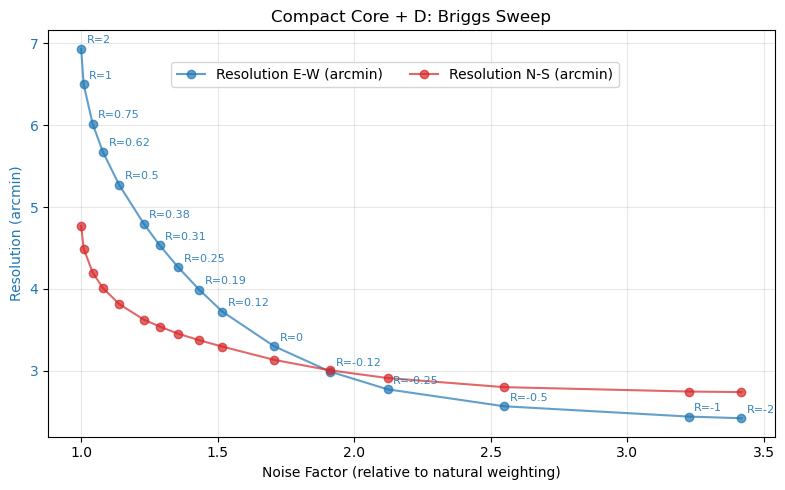

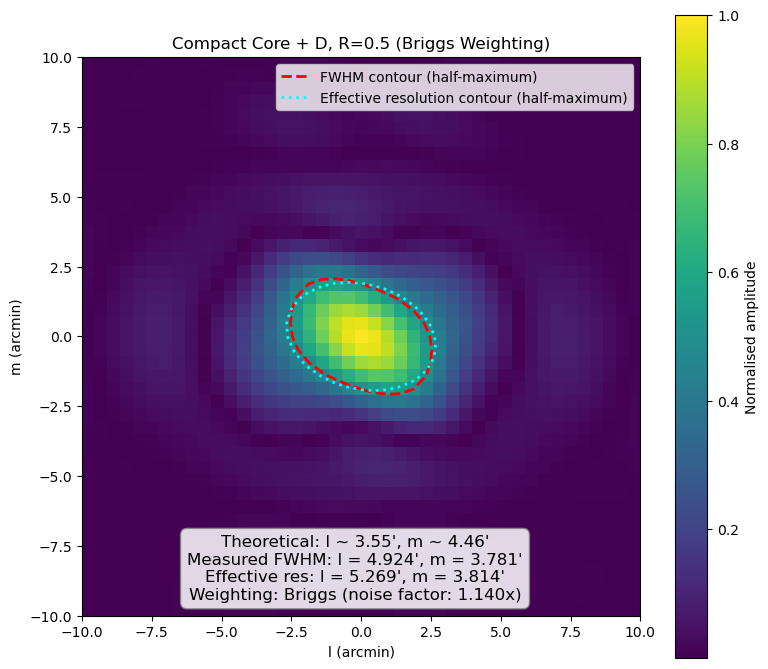

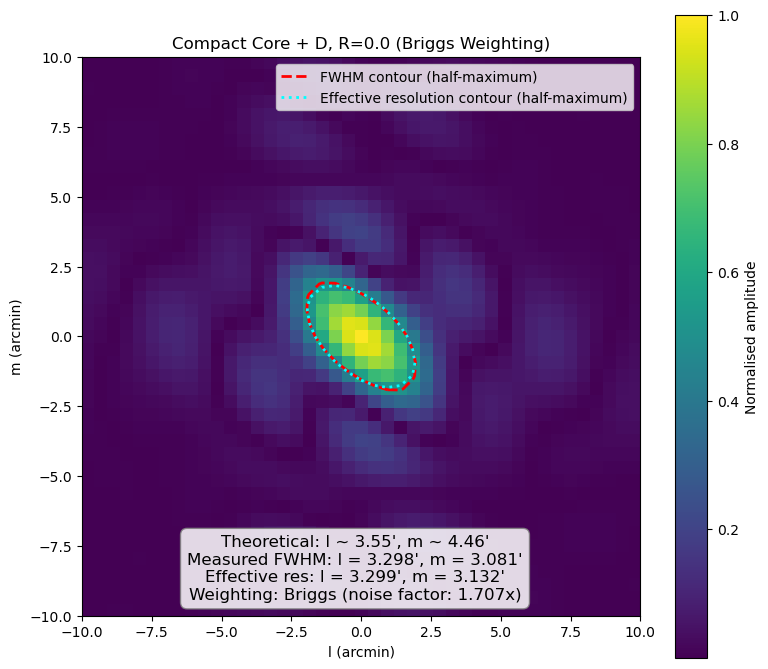

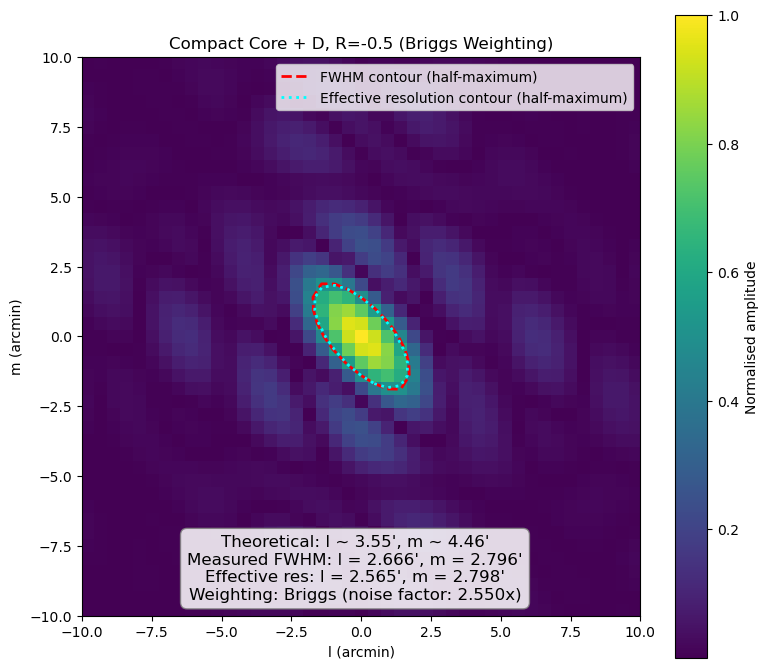

In [25]:
uvd_compact_D = setup_uvdata(compact_D, drao_loc, freq_hz=FREQ_HZ)

r_arr, nf_arr, eff_l_arr, eff_m_arr = adaptive_briggs_sweep(
    uvd_compact_D, tol=0.5, npix=256, image_extent_deg=1,
)

plot_briggs_values("Compact Core + D: Briggs Sweep", r_arr, nf_arr, eff_l_arr, eff_m_arr)

for R in [0.5, 0.0, -0.5]:
    _ = compute_dirty_beam(uvd_compact_D, title=f"Compact Core + D, R={R}",
                    npix=npix, freq_hz=FREQ_HZ, image_extent_deg=1, robust = R, weighting="briggs", zoom_extent=10)

## Compact + E

Unknown polarization basis -- assuming linearly polarized (x/y) feeds for Telescope.feed_array.
Parameter feed_array, feed_angle, and mount_type must be set together. Unsetting optional parameters.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.
Recalculating uvw_array without adjusting visibility phases -- this can introduce significant errors if used incorrectly.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.


Sampled 26 robust values in 24 bisections, total iterations: 24


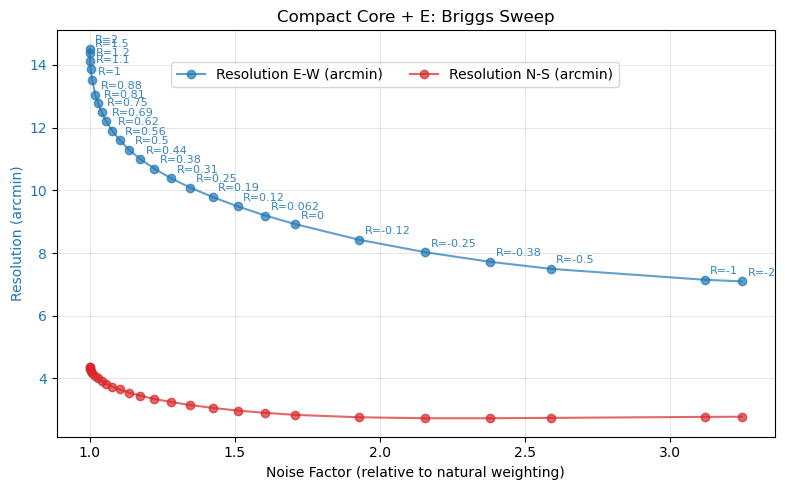

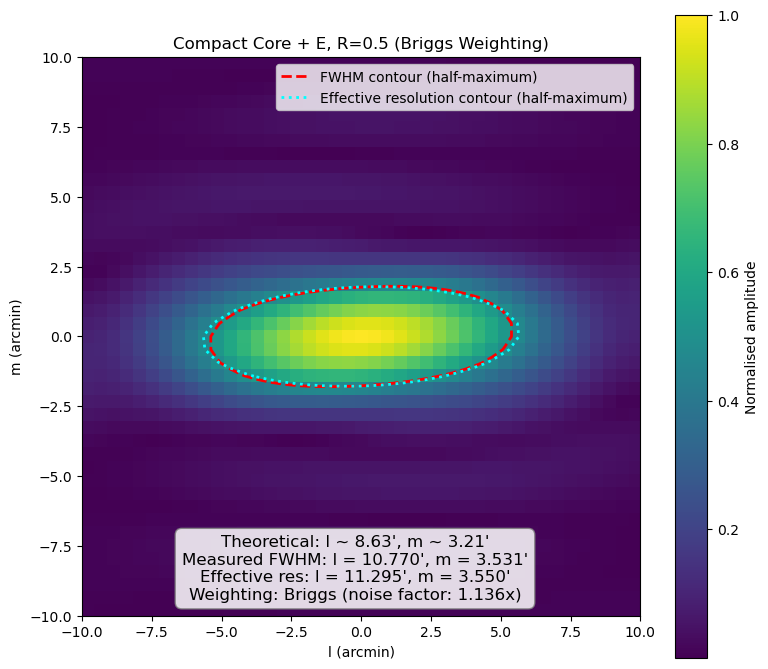

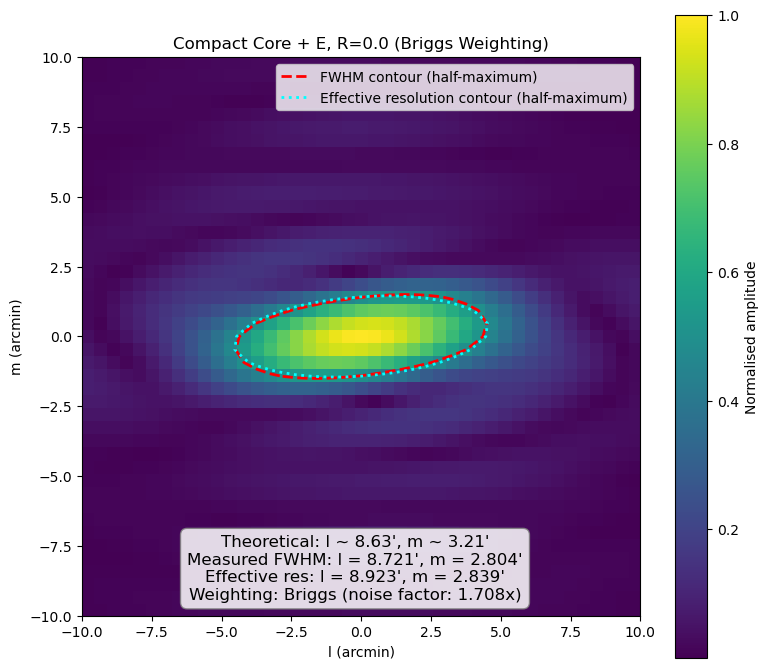

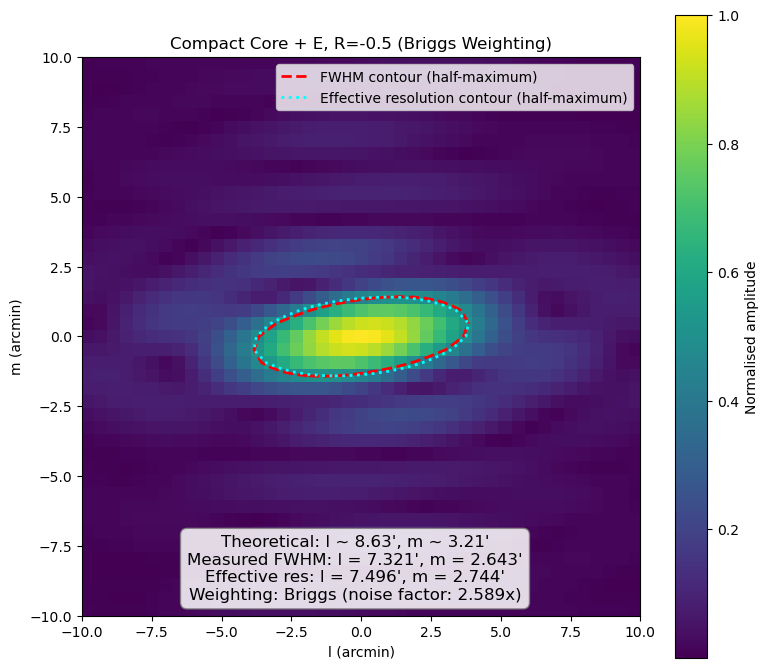

In [ ]:
uvd_compact_E = setup_uvdata(compact_E, drao_loc, freq_hz=FREQ_HZ)

r_arr, nf_arr, eff_l_arr, eff_m_arr = adaptive_briggs_sweep(
    uvd_compact_E, tol=0.5, npix=256, image_extent_deg=1,
)

plot_briggs_values("Compact Core + E: Briggs Sweep", r_arr, nf_arr, eff_l_arr, eff_m_arr)

for R in [0.5, 0.0, -0.5]:
    _ = compute_dirty_beam(uvd_compact_E, title=f"Compact Core + E, R={R}",
                    npix=npix, freq_hz=FREQ_HZ, image_extent_deg=1, robust = R, weighting="briggs", zoom_extent=10)

## Compact + F

Unknown polarization basis -- assuming linearly polarized (x/y) feeds for Telescope.feed_array.
Parameter feed_array, feed_angle, and mount_type must be set together. Unsetting optional parameters.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.
Recalculating uvw_array without adjusting visibility phases -- this can introduce significant errors if used incorrectly.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.


Sampled 29 robust values in 27 bisections, total iterations: 27


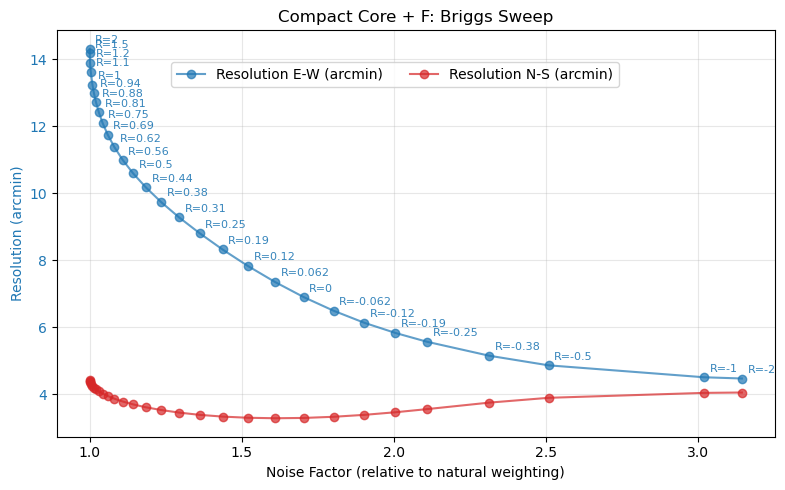

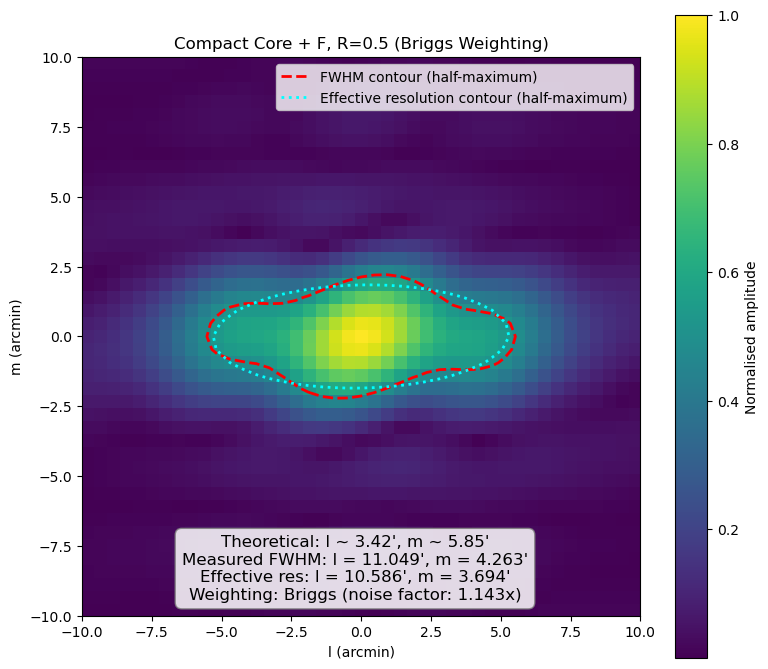

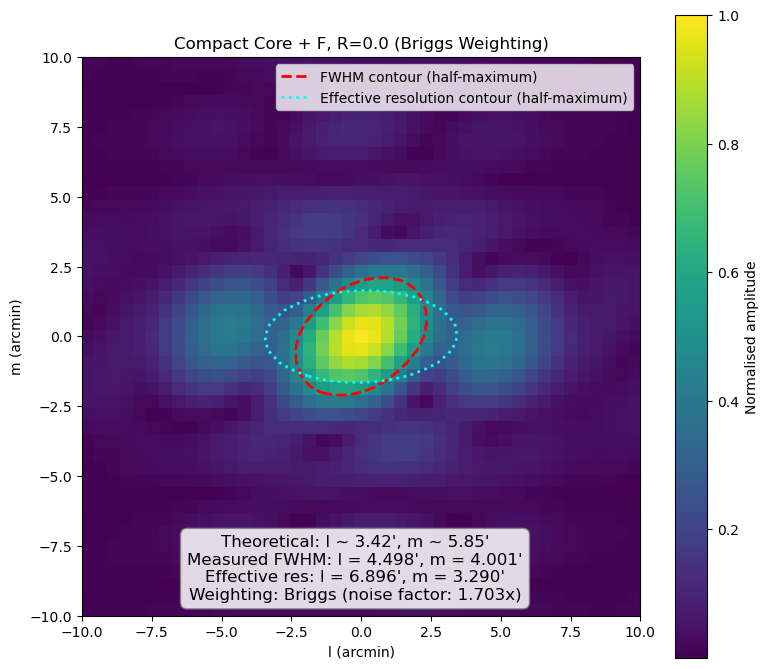

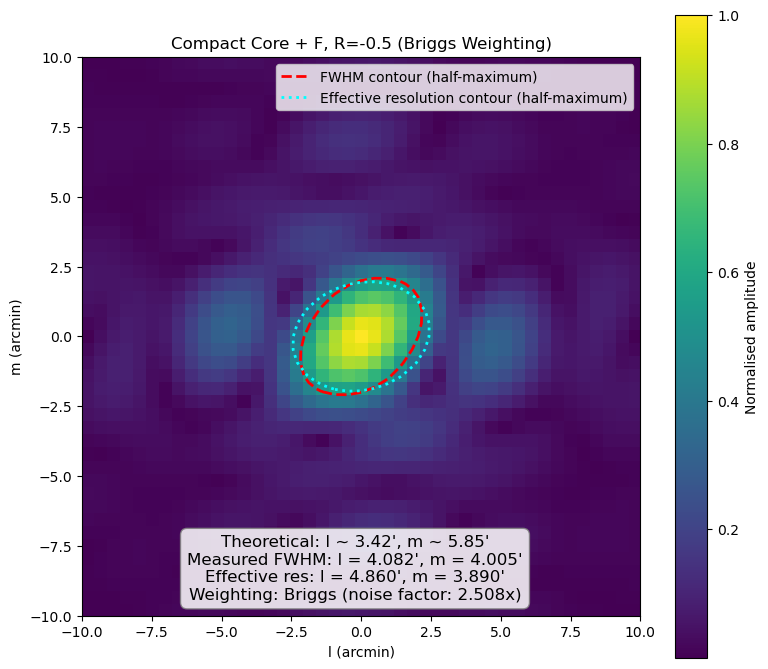

In [ ]:
uvd_compact_F = setup_uvdata(compact_F, drao_loc, freq_hz=FREQ_HZ)

r_arr, nf_arr, eff_l_arr, eff_m_arr = adaptive_briggs_sweep(
    uvd_compact_F, tol=0.5, npix=256, image_extent_deg=1,
)

plot_briggs_values("Compact Core + F: Briggs Sweep", r_arr, nf_arr, eff_l_arr, eff_m_arr)

for R in [0.5, 0.0, -0.5]:
    _ = compute_dirty_beam(uvd_compact_F, title=f"Compact Core + F, R={R}",
                    npix=npix, freq_hz=FREQ_HZ, image_extent_deg=1, robust = R, weighting="briggs", zoom_extent=10)

## Compact + G

Unknown polarization basis -- assuming linearly polarized (x/y) feeds for Telescope.feed_array.
Parameter feed_array, feed_angle, and mount_type must be set together. Unsetting optional parameters.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.
Recalculating uvw_array without adjusting visibility phases -- this can introduce significant errors if used incorrectly.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.


Sampled 31 robust values in 29 bisections, total iterations: 29


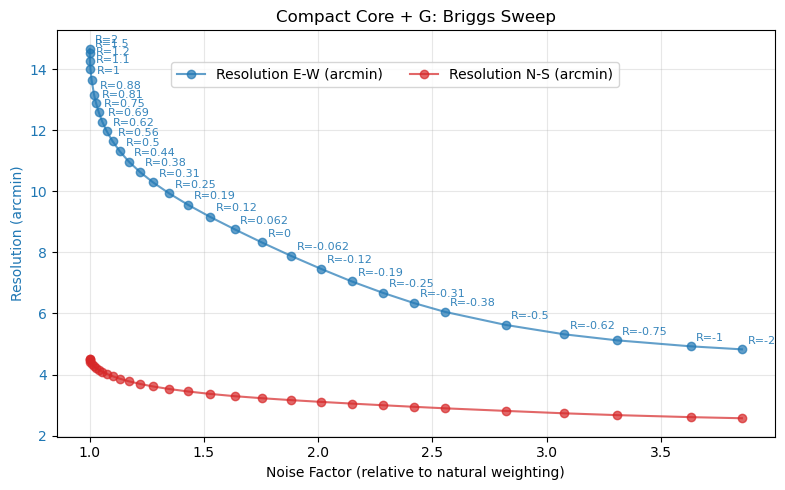

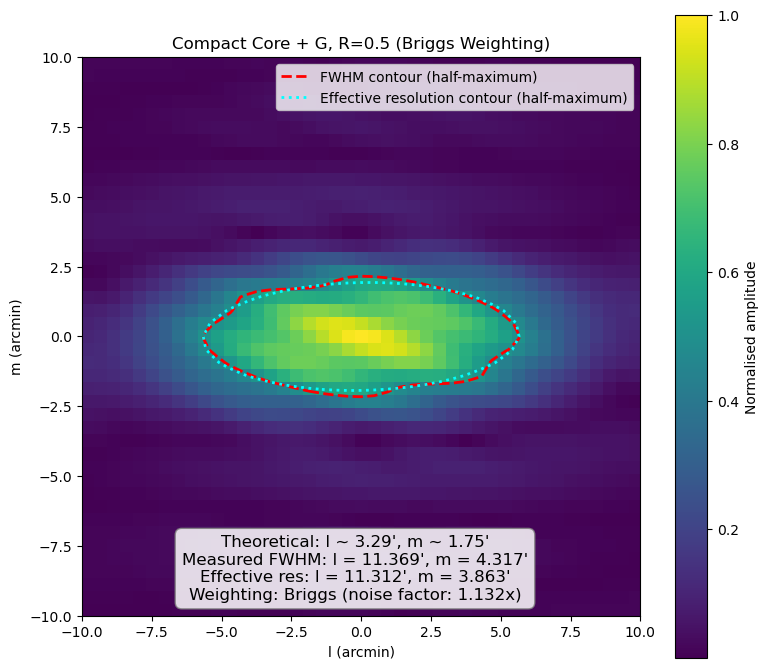

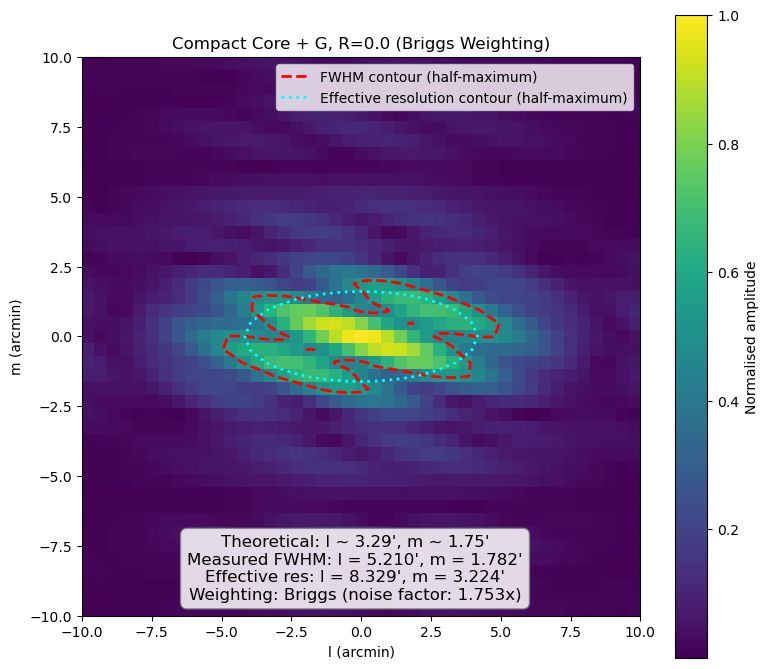

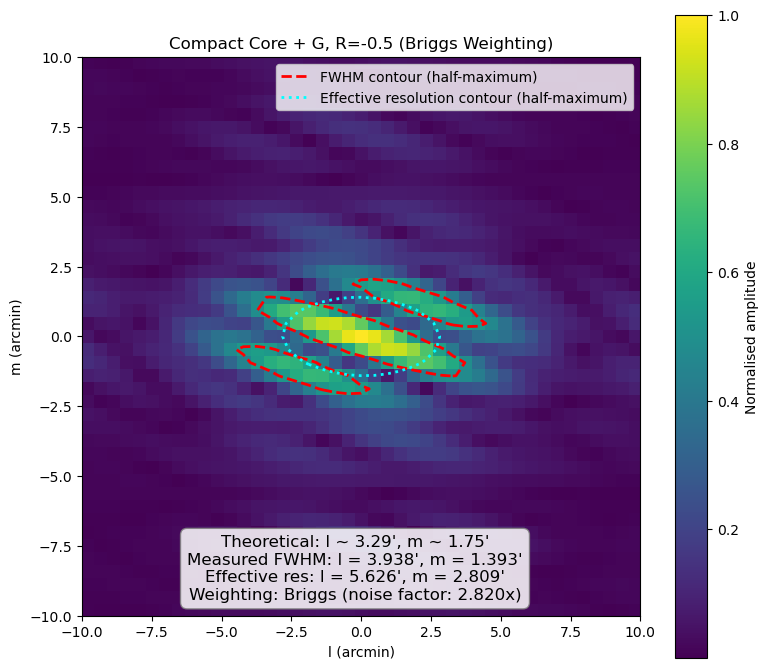

In [ ]:
uvd_compact_G = setup_uvdata(compact_G, drao_loc, freq_hz=FREQ_HZ)

r_arr, nf_arr, eff_l_arr, eff_m_arr = adaptive_briggs_sweep(
    uvd_compact_G, tol=0.5, npix=256, image_extent_deg=1,
)

plot_briggs_values("Compact Core + G: Briggs Sweep", r_arr, nf_arr, eff_l_arr, eff_m_arr)

for R in [0.5, 0.0, -0.5]:
    _ = compute_dirty_beam(uvd_compact_G, title=f"Compact Core + G, R={R}",
                    npix=npix, freq_hz=FREQ_HZ, image_extent_deg=1, robust = R, weighting="briggs", zoom_extent=10)